# Model-specific feature-group selection

This notebook is a **development analysis**, not an untouched outer-test evaluation. It compares predefined feature groups through chronological validation and never uses closing-market performance to select features.

Workflow:

1. Evaluate all 63 nonempty combinations of the six feature groups for every model family.
2. Use the strongest group candidates to seed model-specific floating feature selection.
3. At every refinement step, evaluate all valid one-feature additions and removals.
4. Select the smallest finalist within a small log-loss tolerance of the best development result.
5. Measure both group-level and individual-feature removal effects.
6. Save a separate two-panel removal chart for every model.

Because Scotland has already been inspected repeatedly, selections made here must be frozen and confirmed on another league or a future season.

In [1]:
from __future__ import annotations

import re
import sys
from collections import OrderedDict
from dataclasses import dataclass
from itertools import combinations
from pathlib import Path
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path(r"C:\Users\skous\Super-League-odds-research")
SCOTLAND_RESEARCH = REPO_ROOT / "scotland_research"
assert SCOTLAND_RESEARCH.exists(), SCOTLAND_RESEARCH
sys.path.insert(0, str(SCOTLAND_RESEARCH))

from build_match_features import (
    ADJUSTED_MEAN_FEATURES,
    BASE_SUM_FEATURES,
    DISTRIBUTION_FEATURES,
    LINEUP_FEATURES,
    POSITION_FEATURES,
    RECENCY_MEAN_FEATURES,
    TEAM_STRENGTH_FEATURES,
)
from constants import CLASS_ORDER
from data.load_model_dataset import load_dataset
from evaluation.metrics import score_predictions
from models.dixon_coles_player_form import DixonColesPlayerFormModel
from models.expanded_player_form_lightgbm import ExpandedPlayerFormLightGBMModel
from models.market_plus_player_form import MarketPlusPlayerFormModel
from models.player_form import PlayerFormModel
from models.player_form_lightgbm import PlayerFormLightGBMModel

In [2]:
MODEL_DATASET = REPO_ROOT / "data" / "processed" / "scotland" / "scotland_model_dataset.csv"
OUTPUT_DIR = REPO_ROOT / "artifacts" / "scotland_feature_group_selection"
IMAGE_DIR = SCOTLAND_RESEARCH / "visuals" / "feature_removal_help"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

# If several feature sets are effectively tied, prefer the smaller set.
SELECTION_TOLERANCE = 0.005
# Floating refinement evaluates every one-feature add/remove move at each accepted step.
REFINEMENT_SEEDS = 2
MAX_FLOATING_STEPS = 6
MIN_REFINEMENT_IMPROVEMENT = 0.0005
MODEL_DATASET, OUTPUT_DIR, IMAGE_DIR

(WindowsPath('C:/Users/skous/Super-League-odds-research/data/processed/scotland/scotland_model_dataset.csv'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/artifacts/scotland_feature_group_selection'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/feature_removal_help'))

## Feature groups

Groups are selected instead of individual columns because correlated features can substitute for one another. Single-feature removal would therefore give unstable and misleading importance estimates.

In [3]:
def unique(values: list[str]) -> list[str]:
    return list(dict.fromkeys(values))

FEATURE_GROUPS = OrderedDict(
    [
        (
            "legacy_player_form",
            unique(
                [
                    *BASE_SUM_FEATURES,
                    "rating_mean_5",
                    "starters_without_history",
                    "starters_without_full_window",
                ]
            ),
        ),
        ("team_strength", list(TEAM_STRENGTH_FEATURES)),
        ("opponent_adjusted_form", list(ADJUSTED_MEAN_FEATURES)),
        ("lineup_continuity", list(LINEUP_FEATURES)),
        ("position_and_distribution", unique(POSITION_FEATURES + DISTRIBUTION_FEATURES)),
        ("recency", list(RECENCY_MEAN_FEATURES)),
    ]
)

CANDIDATE_FEATURE_SETS: OrderedDict[str, list[str]] = OrderedDict()
CANDIDATE_GROUPS: dict[str, tuple[str, ...]] = {}
group_names = list(FEATURE_GROUPS)
for group_count in range(1, len(group_names) + 1):
    for selected_groups in combinations(group_names, group_count):
        feature_set_name = " + ".join(selected_groups)
        features = unique(
            [feature for group in selected_groups for feature in FEATURE_GROUPS[group]]
        )
        CANDIDATE_FEATURE_SETS[feature_set_name] = features
        CANDIDATE_GROUPS[feature_set_name] = selected_groups

ALL_BASE_FEATURES = unique(
    [feature for group_features in FEATURE_GROUPS.values() for feature in group_features]
)

pd.DataFrame(
    [
        {"feature_set": name, "groups": CANDIDATE_GROUPS[name], "base_feature_count": len(features)}
        for name, features in CANDIDATE_FEATURE_SETS.items()
    ]
)

,feature_set,groups,base_feature_count
0,legacy_player_form,"(legacy_player_form,)",7
1,team_strength,"(team_strength,)",8
2,opponent_adjusted_form,"(opponent_adjusted_form,)",24
3,lineup_continuity,"(lineup_continuity,)",7
4,position_and_distribution,"(position_and_distribution,)",20
...,...,...,...
58,legacy_player_form + team_strength + opponent_...,"(legacy_player_form, team_strength, opponent_a...",76
59,legacy_player_form + team_strength + lineup_co...,"(legacy_player_form, team_strength, lineup_con...",59
60,legacy_player_form + opponent_adjusted_form + ...,"(legacy_player_form, opponent_adjusted_form, l...",75
61,team_strength + opponent_adjusted_form + lineu...,"(team_strength, opponent_adjusted_form, lineup...",76


## Chronological development folds

Every validation season is predicted only from earlier seasons. These are now development folds because their results have already been viewed. They must not be described as untouched confirmation after feature selection.

In [4]:
dataset = load_dataset(MODEL_DATASET)

def ordered_seasons(frame: pd.DataFrame) -> list[str]:
    return (
        frame.groupby("season")["_match_datetime"]
        .min()
        .sort_values()
        .index.astype(str)
        .tolist()
    )

def development_folds(frame: pd.DataFrame):
    seasons = ordered_seasons(frame)
    for validation_index in range(1, len(seasons)):
        train_seasons = seasons[:validation_index]
        validation_season = seasons[validation_index]
        train = frame[frame["season"].isin(train_seasons)].copy()
        validation = frame[frame["season"].eq(validation_season)].copy()

        if set(train["result_3way"]) != set(CLASS_ORDER):
            raise ValueError(f"Training data before {validation_season} lacks an outcome class")
        yield train, validation, validation_season

[(season, len(train), len(validation)) for train, validation, season in development_folds(dataset)]

C:\Users\skous\Super-League-odds-research\scotland_research\data\load_model_dataset.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["_match_datetime"] = pd.to_datetime(
C:\Users\skous\Super-League-odds-research\scotland_research\data\load_model_dataset.py:66: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["market_log_home_vs_draw"] = np.log(
C:\Users\skous\Super-League-odds-research\scotland_research\data\load_model_dataset.py:69: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of 

[('2021-22', 228, 228),
 ('2022-23', 456, 226),
 ('2023-24', 682, 212),
 ('2024-25', 894, 227)]

## Model families

Difference models receive home-minus-away columns. The expanded LightGBM receives separate home and away columns. Each model is compared only with itself across feature sets. Hyperparameter tuning should be rerun after a feature set is frozen.

In [5]:
@dataclass(frozen=True)
class ModelSpec:
    name: str
    label: str
    representation: str
    factory: Callable[[list[str], str], object]

def representation_columns(base_features: list[str], representation: str) -> list[str]:
    if representation == "diff":
        return [f"diff_{feature}" for feature in base_features]
    if representation == "expanded":
        return [f"{side}_{feature}" for side in ("home", "away") for feature in base_features]
    raise ValueError(f"Unknown representation: {representation}")

MODEL_SPECS = [
    ModelSpec("player_form_logistic", "Player-form logistic", "diff",lambda columns, name: PlayerFormModel(player_features=columns, name=name)),
    ModelSpec("market_plus_player_form", "Market + player-form logistic", "diff", lambda columns, name: MarketPlusPlayerFormModel(player_features=columns, name=name)),
    ModelSpec("dixon_coles_player_form", "Dixon–Coles + player form", "diff", lambda columns, name: DixonColesPlayerFormModel(player_features=columns, name=name)),
    ModelSpec("player_form_lightgbm", "Player-form LightGBM", "diff", lambda columns, name: PlayerFormLightGBMModel(player_features=columns, name=name)),
    ModelSpec("expanded_player_form_lightgbm", "Expanded player-form LightGBM", "expanded", lambda columns, name: ExpandedPlayerFormLightGBMModel(player_features=columns, name=name))
]

pd.DataFrame([{"model": spec.name, "representation": spec.representation} for spec in MODEL_SPECS])

,model,representation
0,player_form_logistic,diff
1,market_plus_player_form,diff
2,dixon_coles_player_form,diff
3,player_form_lightgbm,diff
4,expanded_player_form_lightgbm,expanded


The production Poisson and multinomial GAMs use curated transformed variables rather than the generic `TEAM_FEATURES` registry. Their spline-basis and feature-group selection should therefore be performed through their constructors, not by silently zeroing or deleting raw columns here.

In [6]:
dixon_coles_diagnostic_frames = []
evaluation_cache = {}

def evaluate_model_feature_set(
    frame: pd.DataFrame,
    spec: ModelSpec,
    feature_set_name: str,
    base_features: list[str],
) -> tuple[pd.DataFrame, dict[str, object]]:
    columns = representation_columns(base_features, spec.representation)
    missing = sorted(set(columns).difference(frame.columns))
    if missing:
        raise ValueError(f"{spec.name}/{feature_set_name} missing columns: {missing[:10]}")

    cache_key = (spec.name, tuple(columns))
    if cache_key in evaluation_cache:
        cached_folds, cached_summary = evaluation_cache[cache_key]
        folds = cached_folds.copy()
        folds["feature_set"] = feature_set_name
        summary = cached_summary.copy()
        summary["feature_set"] = feature_set_name
        return folds, summary

    fold_rows = []
    for train, validation, validation_season in development_folds(frame):
        model_name = f"{spec.name}__{feature_set_name}"
        model = spec.factory(columns, model_name)
        model.fit(train)
        probabilities = model.predict_proba(validation)
        rho_adjustment_count = 0
        estimator = getattr(model, "_estimator", None)
        diagnostics = getattr(estimator, "last_prediction_diagnostics", pd.DataFrame())
        if not diagnostics.empty:
            diagnostics = diagnostics.copy()
            diagnostics.insert(0, "model", spec.name)
            diagnostics.insert(1, "feature_set", feature_set_name)
            diagnostics.insert(2, "validation_season", validation_season)
            dixon_coles_diagnostic_frames.append(diagnostics)
            rho_adjustment_count = int(diagnostics["rho_adjusted"].sum())
            if rho_adjustment_count:
                print(f"Adjusted rho for {rho_adjustment_count} fixtures: {spec.name}/{feature_set_name}/{validation_season}")
        scores = score_predictions(validation["result_3way"], probabilities)
        fold_rows.append(
            {
                "model": spec.name,
                "model_label": spec.label,
                "feature_set": feature_set_name,
                "validation_season": validation_season,
                "train_matches": len(train),
                "validation_matches": len(validation),
                "base_feature_count": len(base_features),
                "model_column_count": len(columns),
                "rho_adjustment_count": rho_adjustment_count,
                **scores,
            }
        )

    folds = pd.DataFrame(fold_rows)
    weights = folds["validation_matches"] / folds["validation_matches"].sum()
    summary = {
        "model": spec.name,
        "model_label": spec.label,
        "feature_set": feature_set_name,
        "base_feature_count": len(base_features),
        "model_column_count": len(columns),
        "mean_log_loss": float(np.dot(weights, folds["log_loss"])),
        "worst_fold_log_loss": float(folds["log_loss"].max()),
        "fold_log_loss_std": float(folds["log_loss"].std(ddof=0)),
        "mean_brier_score": float(np.dot(weights, folds["brier_score"])),
    }
    evaluation_cache[cache_key] = (folds.copy(), summary.copy())
    return folds, summary

## Phase A: exhaustive feature-group combinations

All 63 nonempty combinations of the six feature groups are evaluated independently for every model. This replaces the earlier single cumulative path.

In [7]:
addition_fold_frames = []
addition_summary_rows = []

for spec in MODEL_SPECS:
    for feature_set_name, base_features in CANDIDATE_FEATURE_SETS.items():
        folds, summary = evaluate_model_feature_set(
            dataset, spec, feature_set_name, base_features
        )
        selected_groups = CANDIDATE_GROUPS[feature_set_name]
        folds["selected_groups"] = "|".join(selected_groups)
        summary["selected_groups"] = "|".join(selected_groups)
        summary["group_count"] = len(selected_groups)
        addition_fold_frames.append(folds)
        addition_summary_rows.append(summary)
    # Persist completed models because exhaustive temporal fitting can be slow.
    pd.concat(addition_fold_frames, ignore_index=True).to_csv(
        OUTPUT_DIR / "feature_group_combination_folds_checkpoint.csv", index=False
    )
    pd.DataFrame(addition_summary_rows).to_csv(
        OUTPUT_DIR / "feature_group_combination_summary_checkpoint.csv", index=False
    )

addition_folds = pd.concat(addition_fold_frames, ignore_index=True)
addition_summary = pd.DataFrame(addition_summary_rows)
addition_summary.sort_values(["model", "mean_log_loss", "base_feature_count"])

,model,model_label,feature_set,base_feature_count,model_column_count,mean_log_loss,worst_fold_log_loss,fold_log_loss_std,mean_brier_score,selected_groups,group_count
126,dixon_coles_player_form,Dixon–Coles + player form,legacy_player_form,7,7,0.953444,0.989319,0.037286,0.564700,legacy_player_form,1
129,dixon_coles_player_form,Dixon–Coles + player form,lineup_continuity,7,7,0.954510,0.999336,0.042296,0.565298,lineup_continuity,1
130,dixon_coles_player_form,Dixon–Coles + player form,position_and_distribution,20,20,0.959046,0.997777,0.037926,0.567267,position_and_distribution,1
134,dixon_coles_player_form,Dixon–Coles + player form,legacy_player_form + lineup_continuity,14,14,0.960508,1.007339,0.043393,0.569097,legacy_player_form|lineup_continuity,2
144,dixon_coles_player_form,Dixon–Coles + player form,lineup_continuity + position_and_distribution,27,27,0.965654,1.014172,0.044771,0.570547,lineup_continuity|position_and_distribution,2
...,...,...,...,...,...,...,...,...,...,...,...
44,player_form_logistic,Player-form logistic,legacy_player_form + team_strength + lineup_co...,42,42,1.222217,1.848175,0.364782,0.626165,legacy_player_form|team_strength|lineup_contin...,4
45,player_form_logistic,Player-form logistic,legacy_player_form + team_strength + lineup_co...,39,39,1.237618,1.934068,0.405917,0.629420,legacy_player_form|team_strength|lineup_contin...,4
62,player_form_logistic,Player-form logistic,legacy_player_form + team_strength + opponent_...,83,83,1.252289,1.771769,0.302797,0.664984,legacy_player_form|team_strength|opponent_adju...,6
56,player_form_logistic,Player-form logistic,legacy_player_form + team_strength + opponent_...,66,66,1.259564,1.823409,0.328094,0.663072,legacy_player_form|team_strength|opponent_adju...,5


## Visualize exhaustive group-combination performance

These plots use only Phase A results. For each model they show all 63 group masks, the complexity-performance frontier, and descriptive included-versus-excluded group distributions.

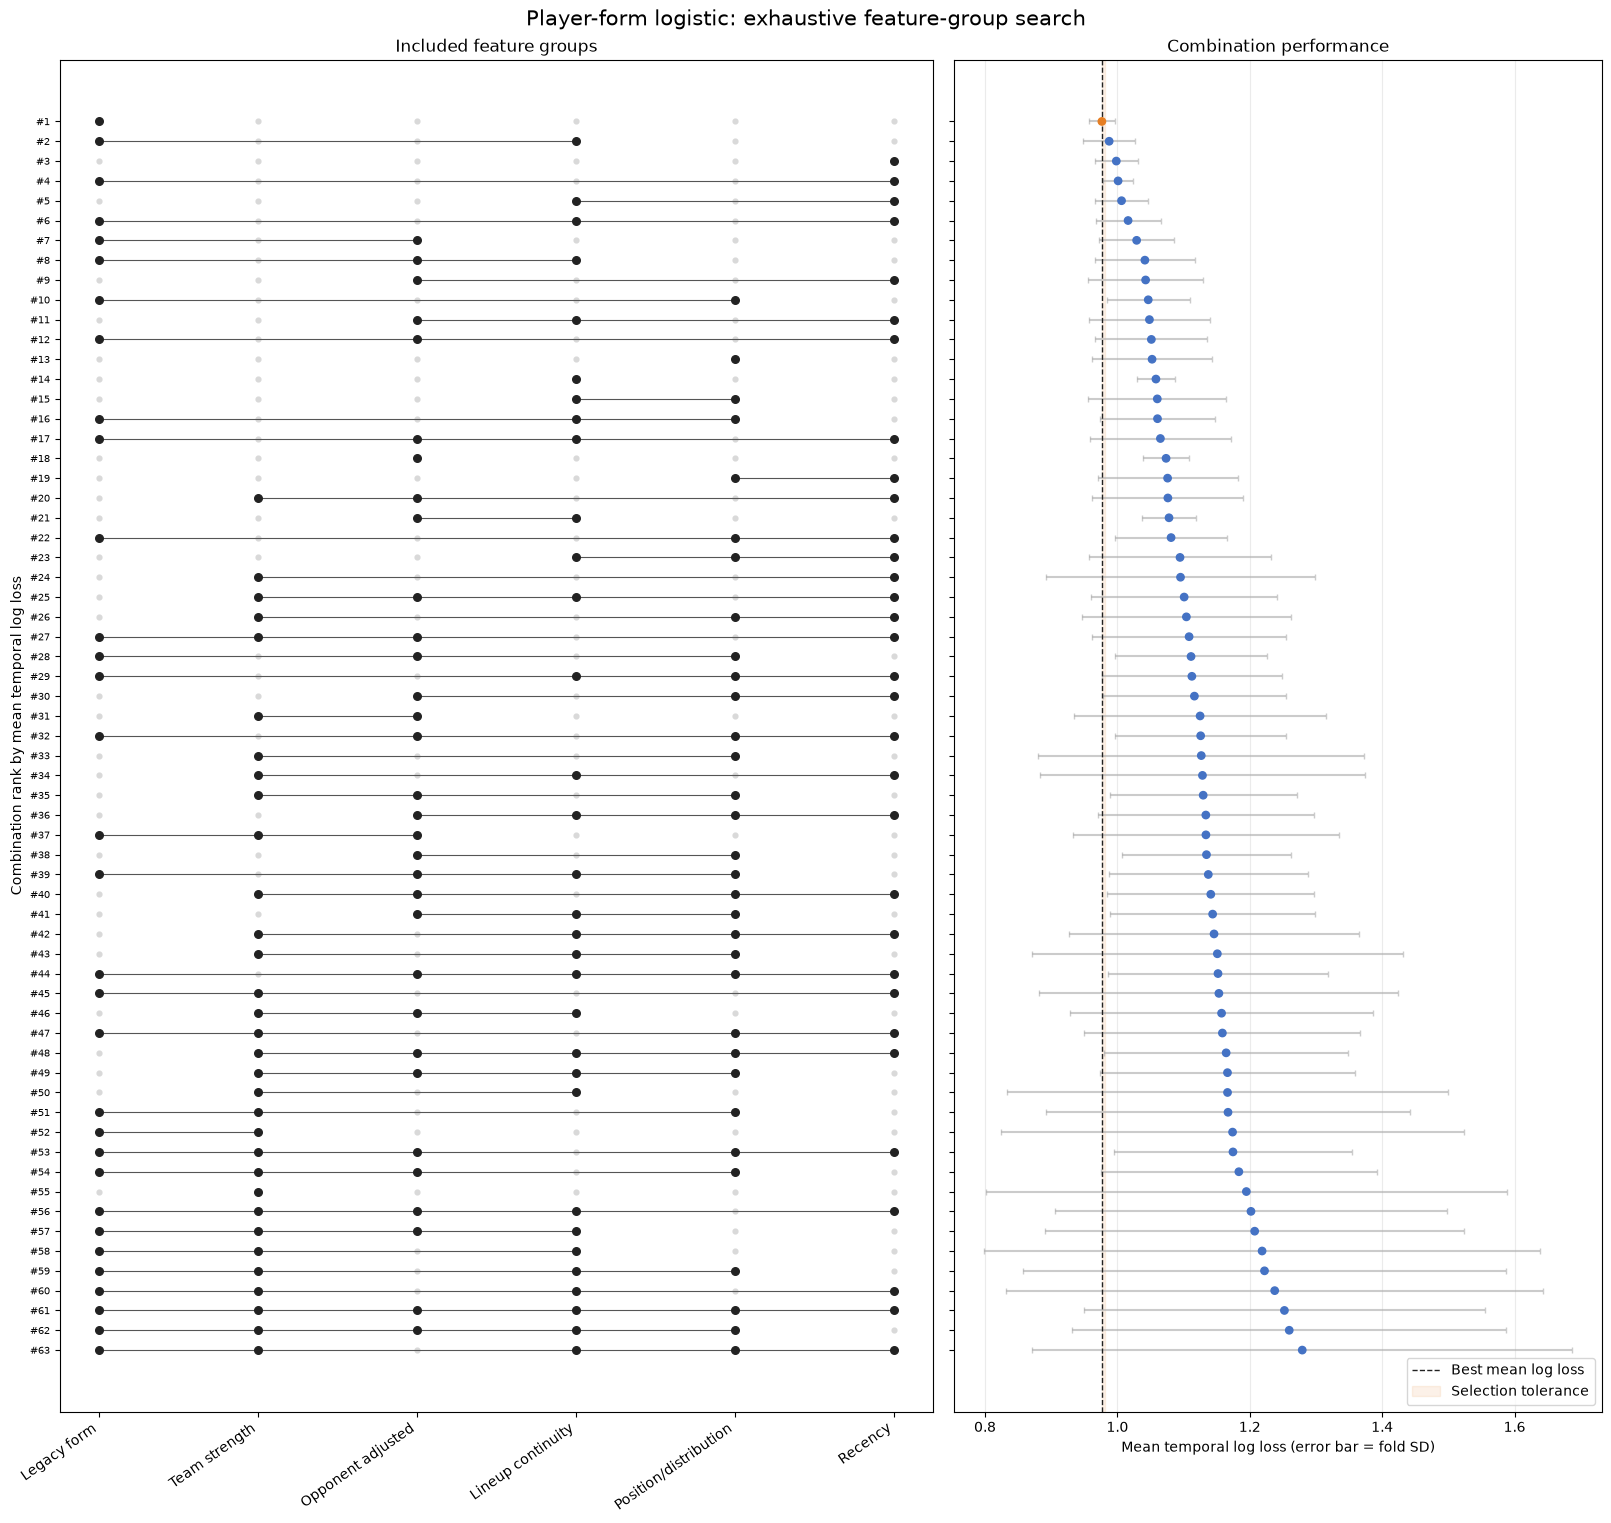

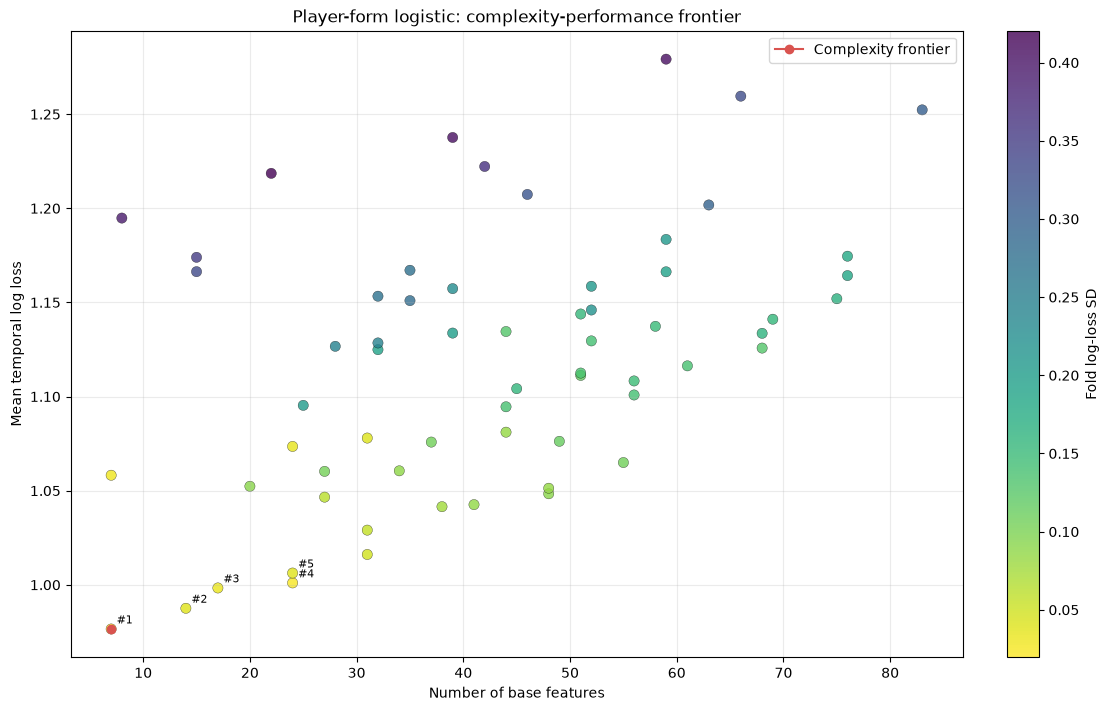

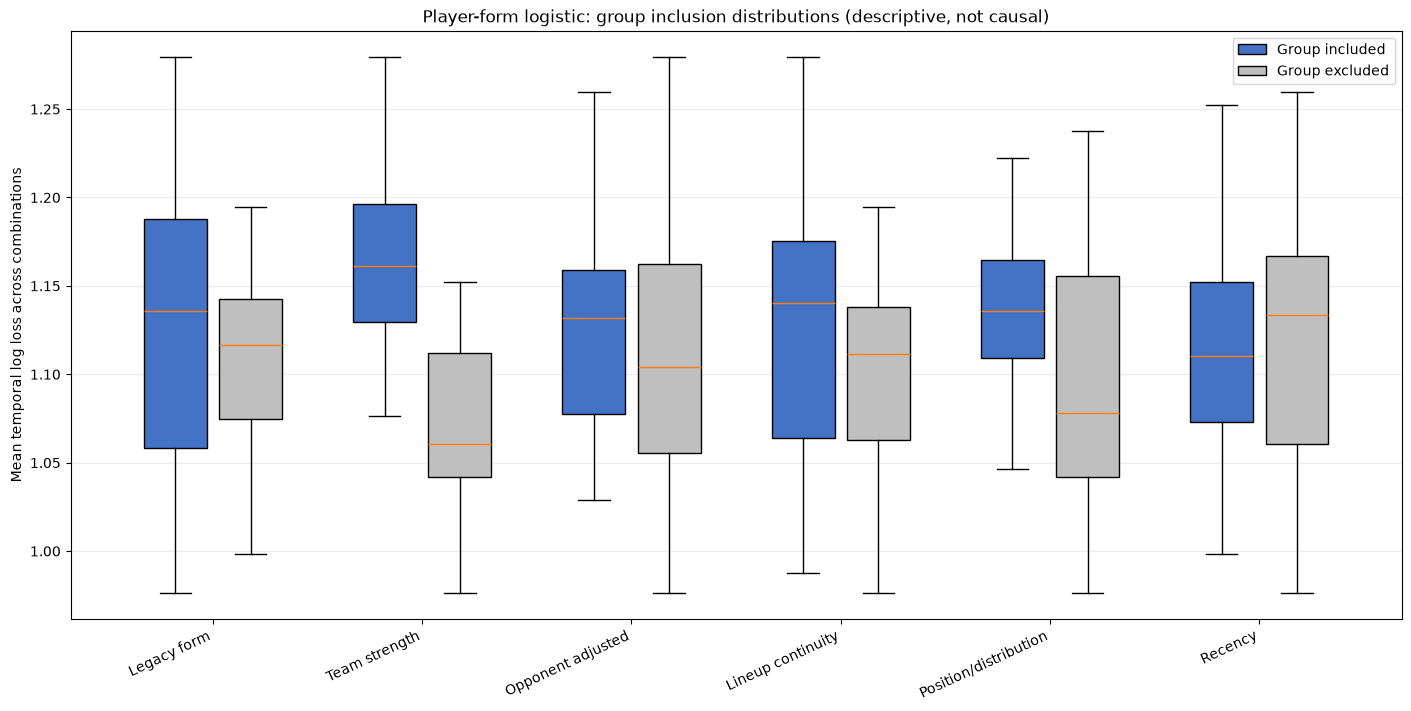

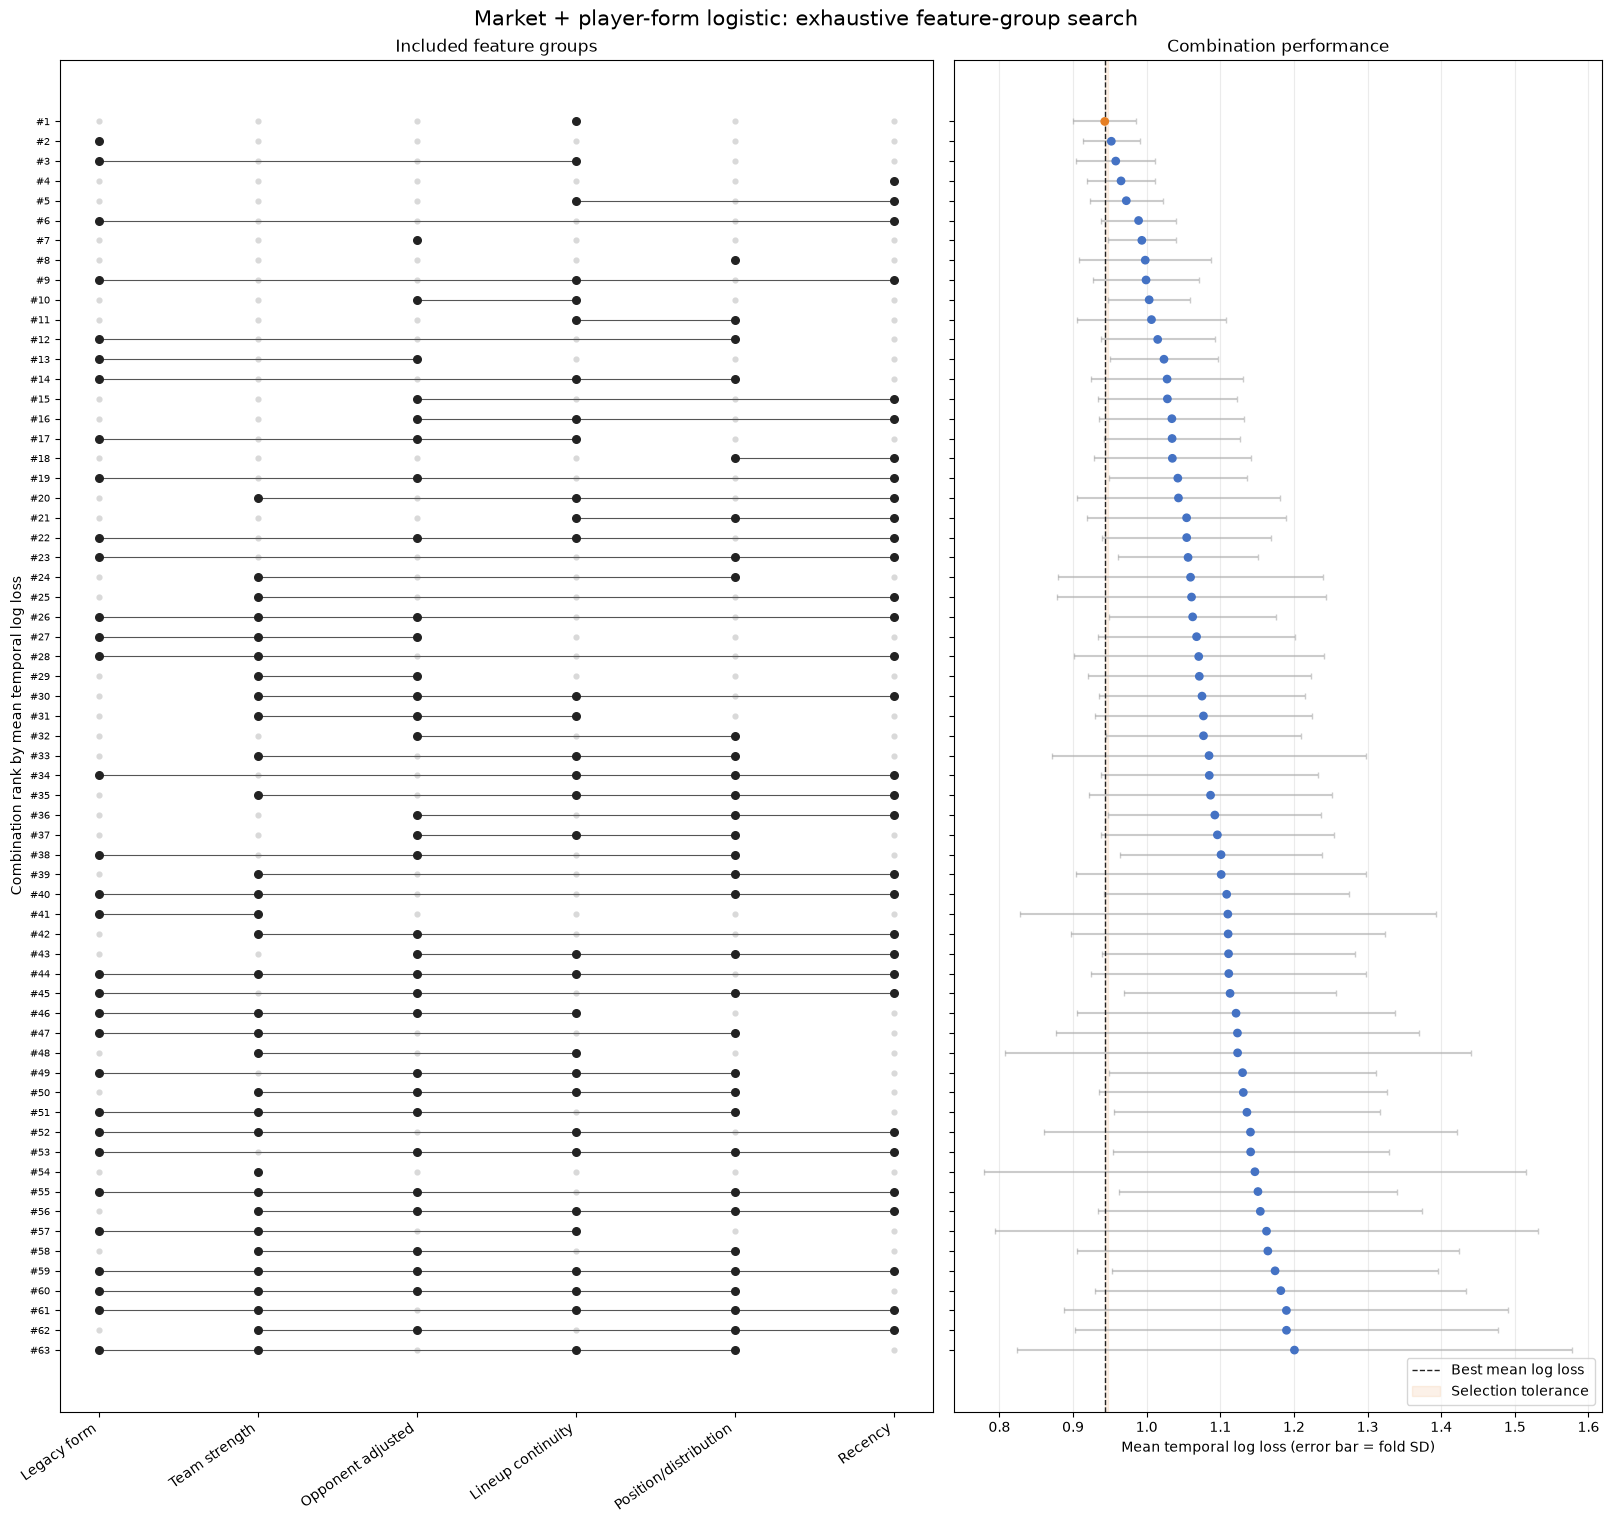

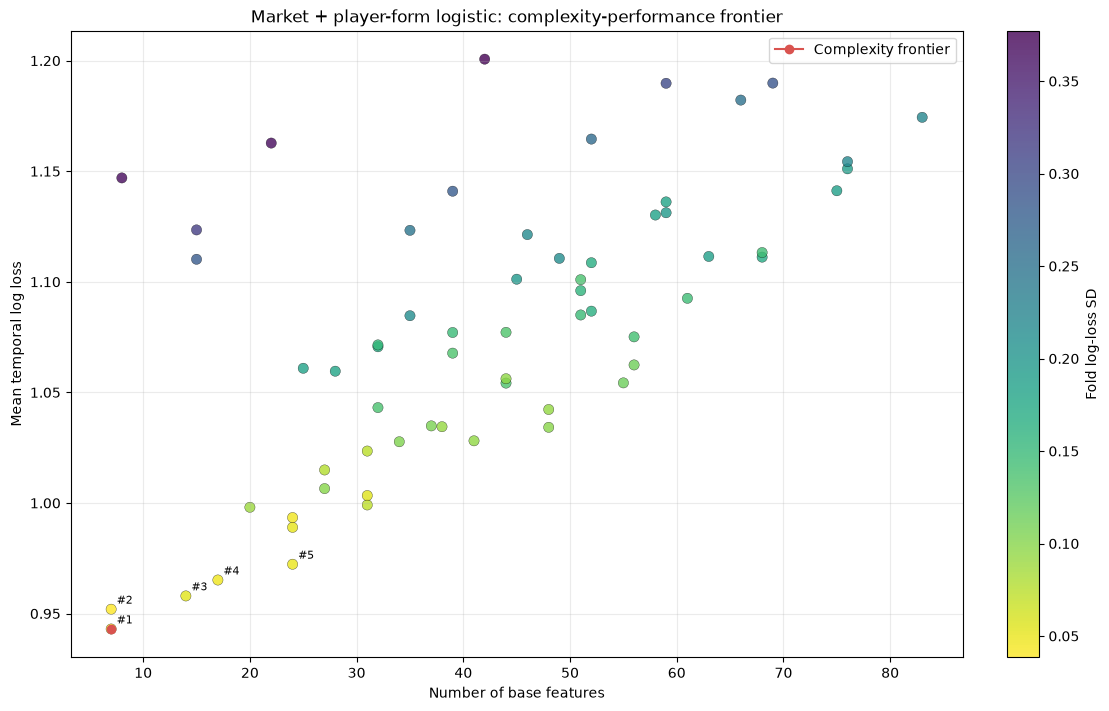

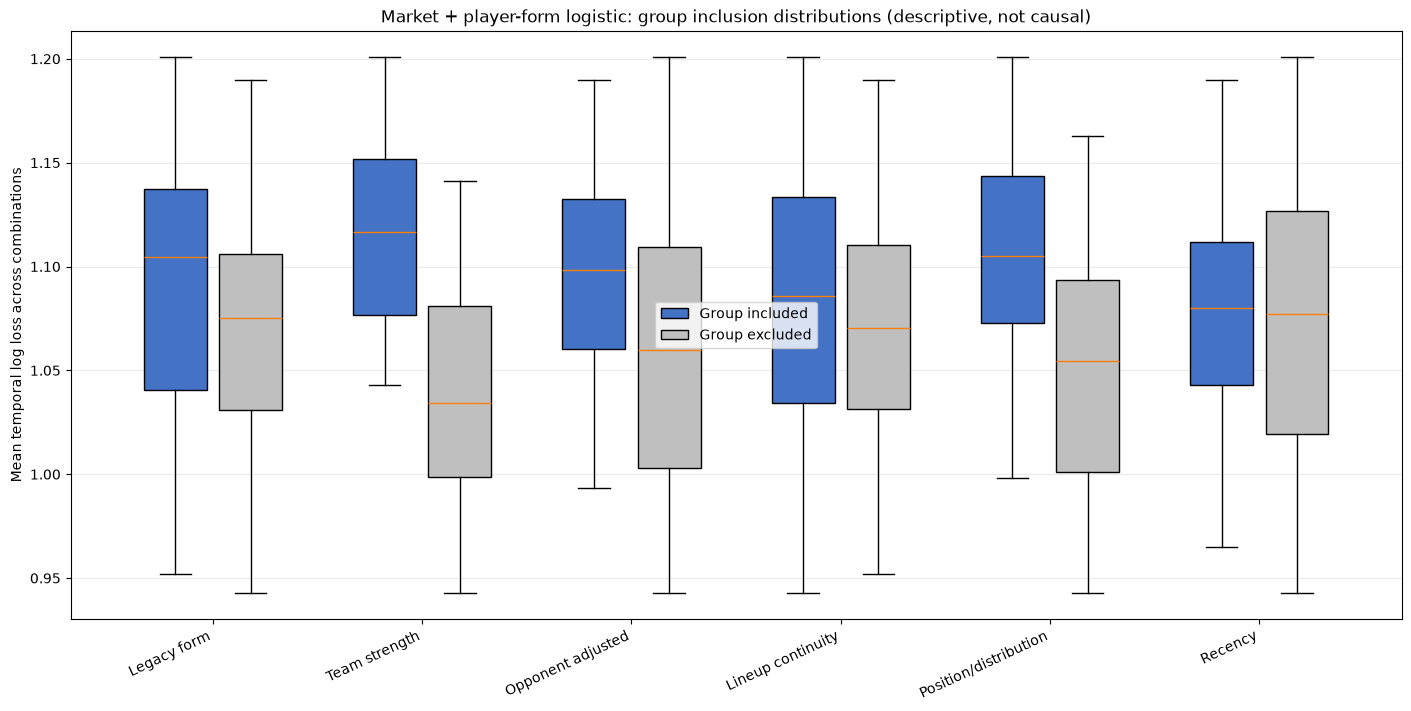

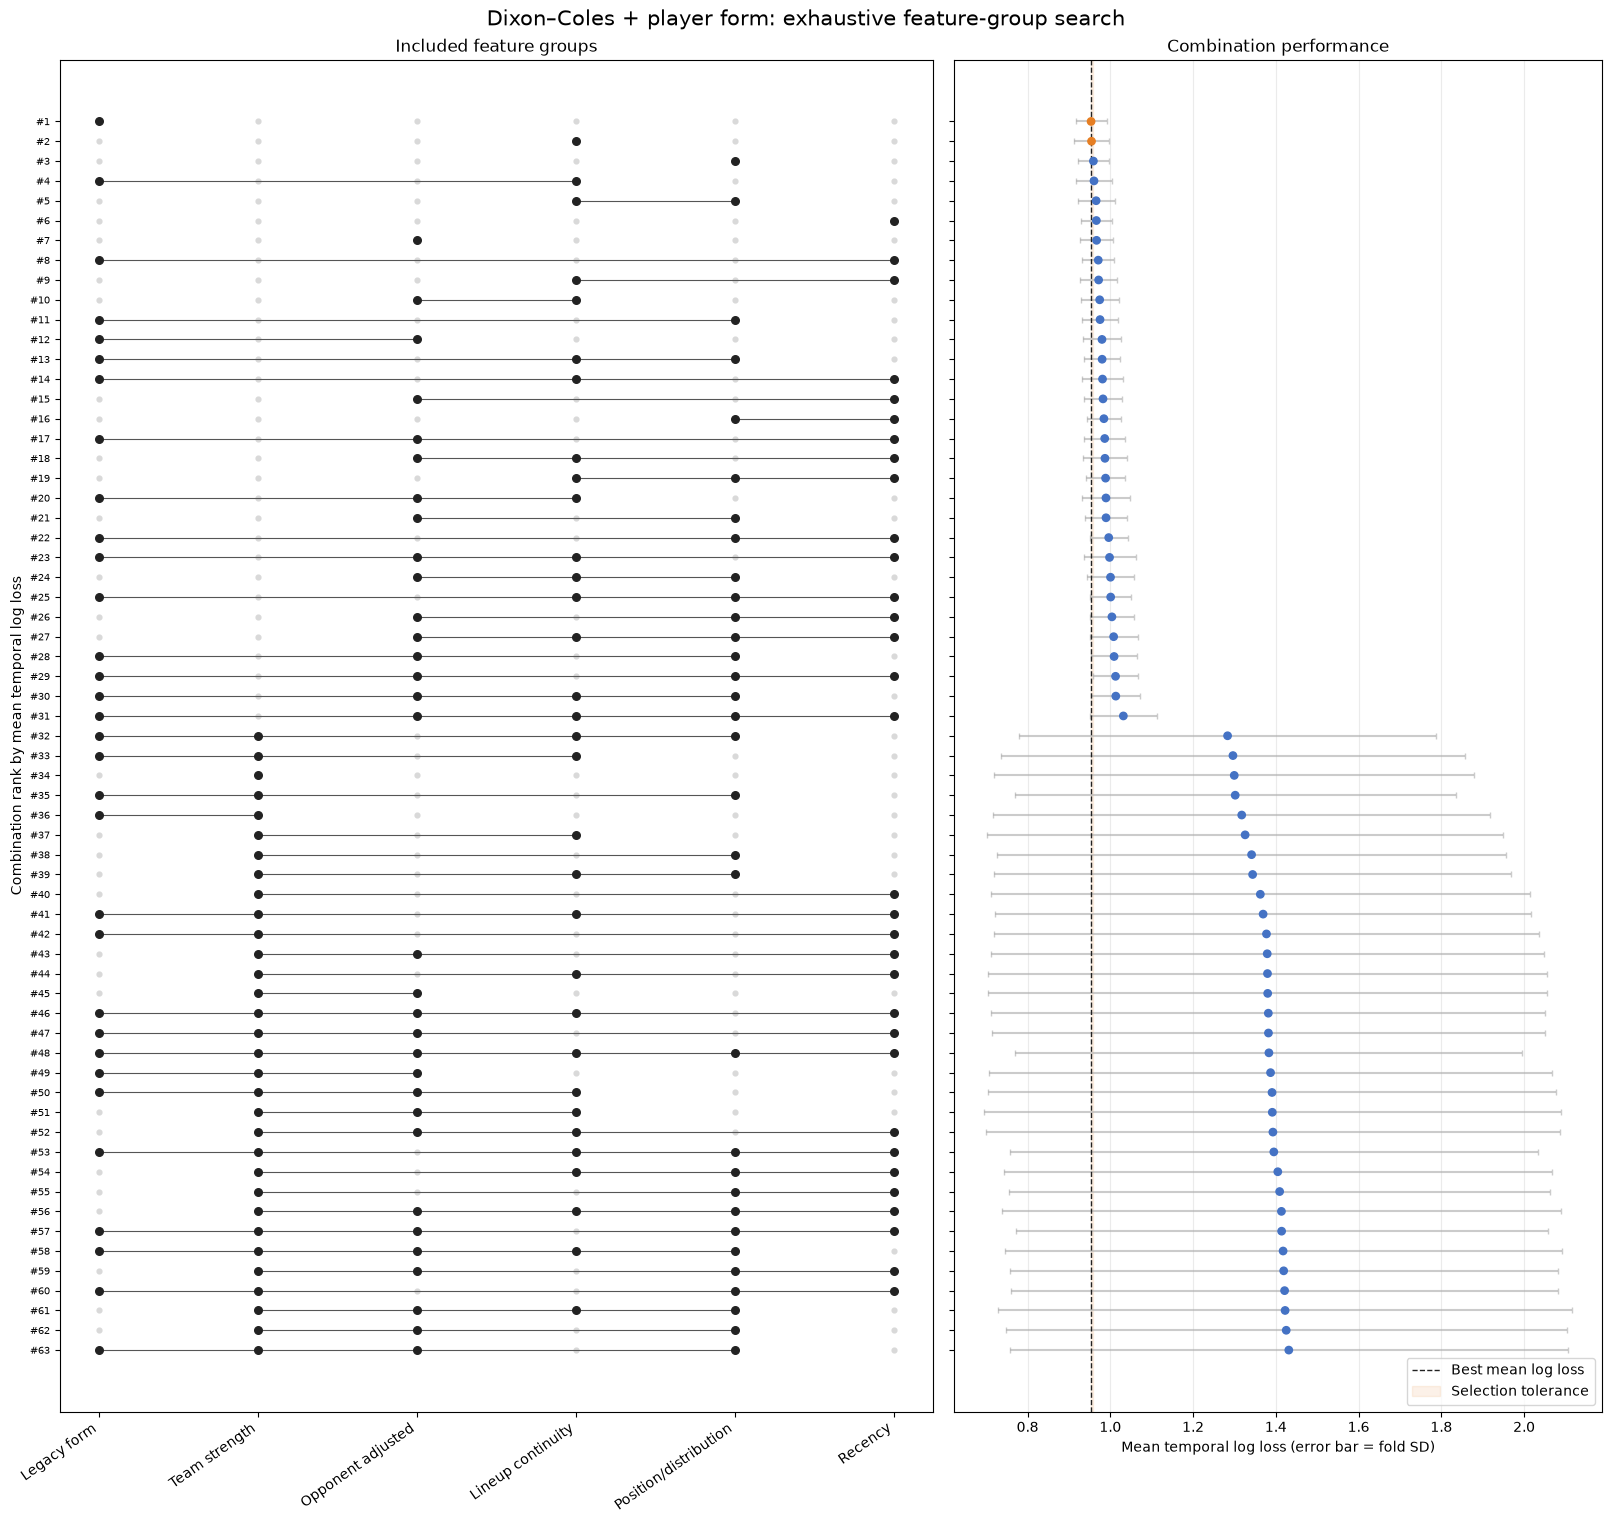

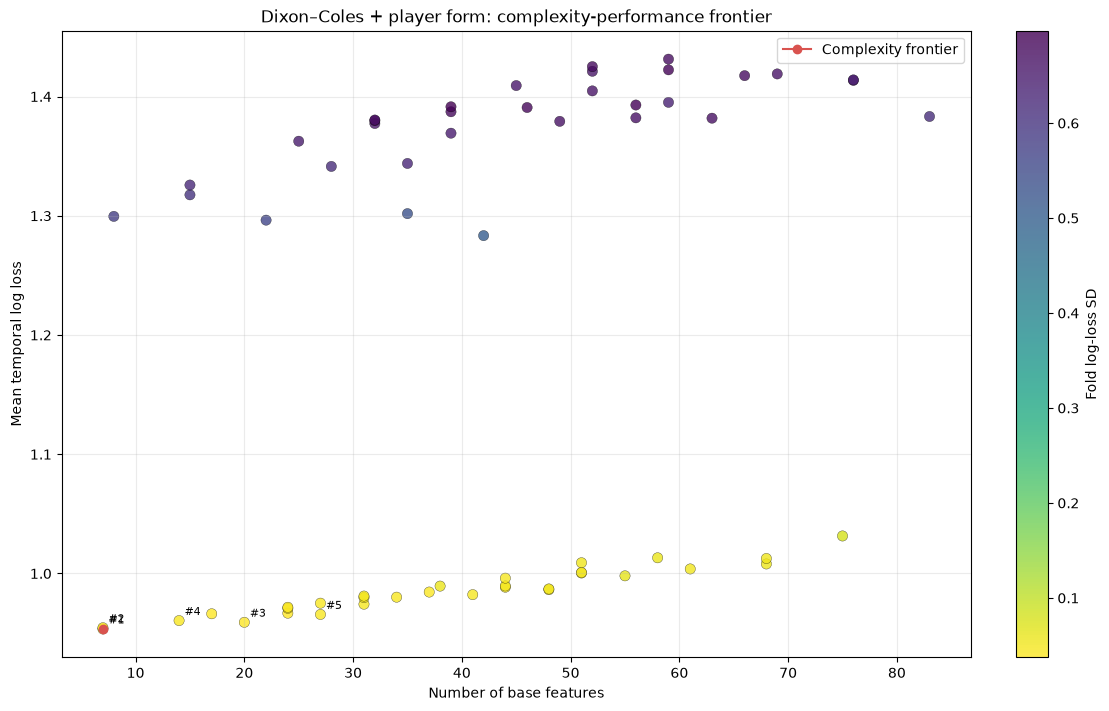

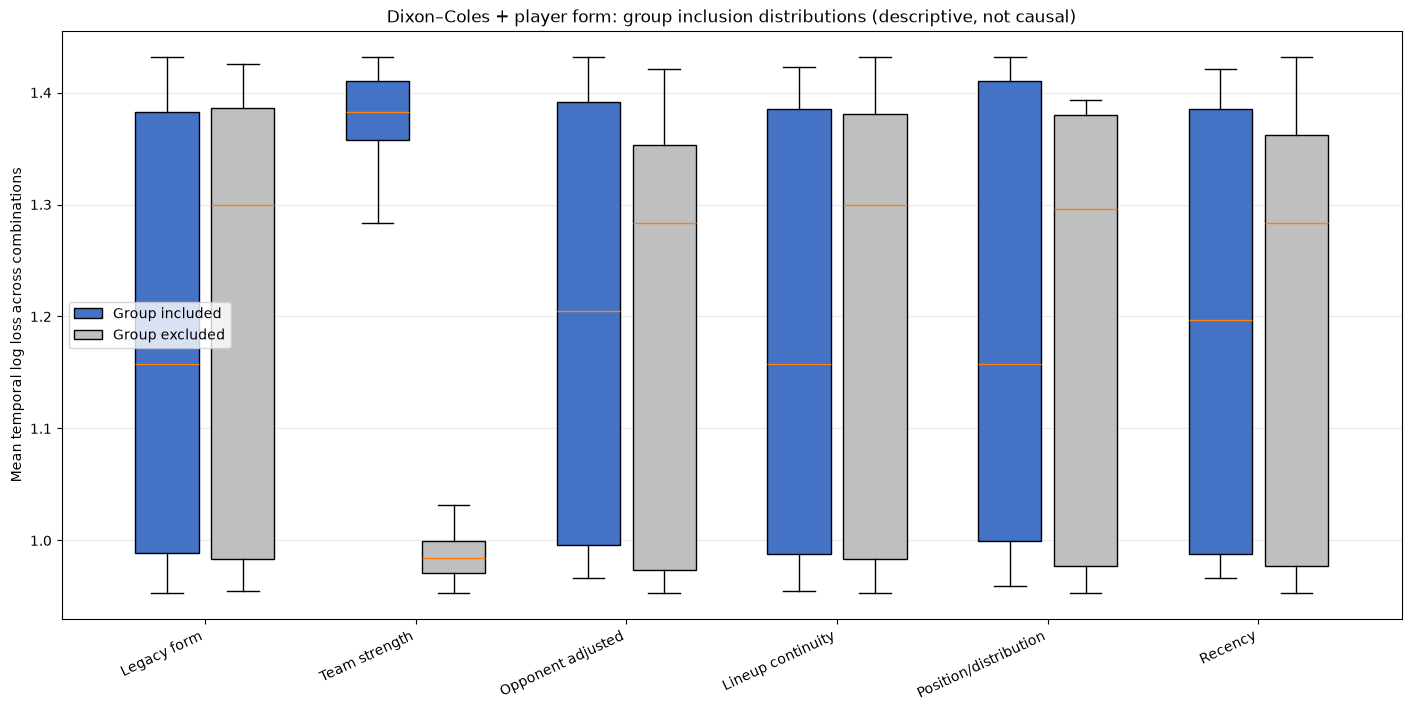

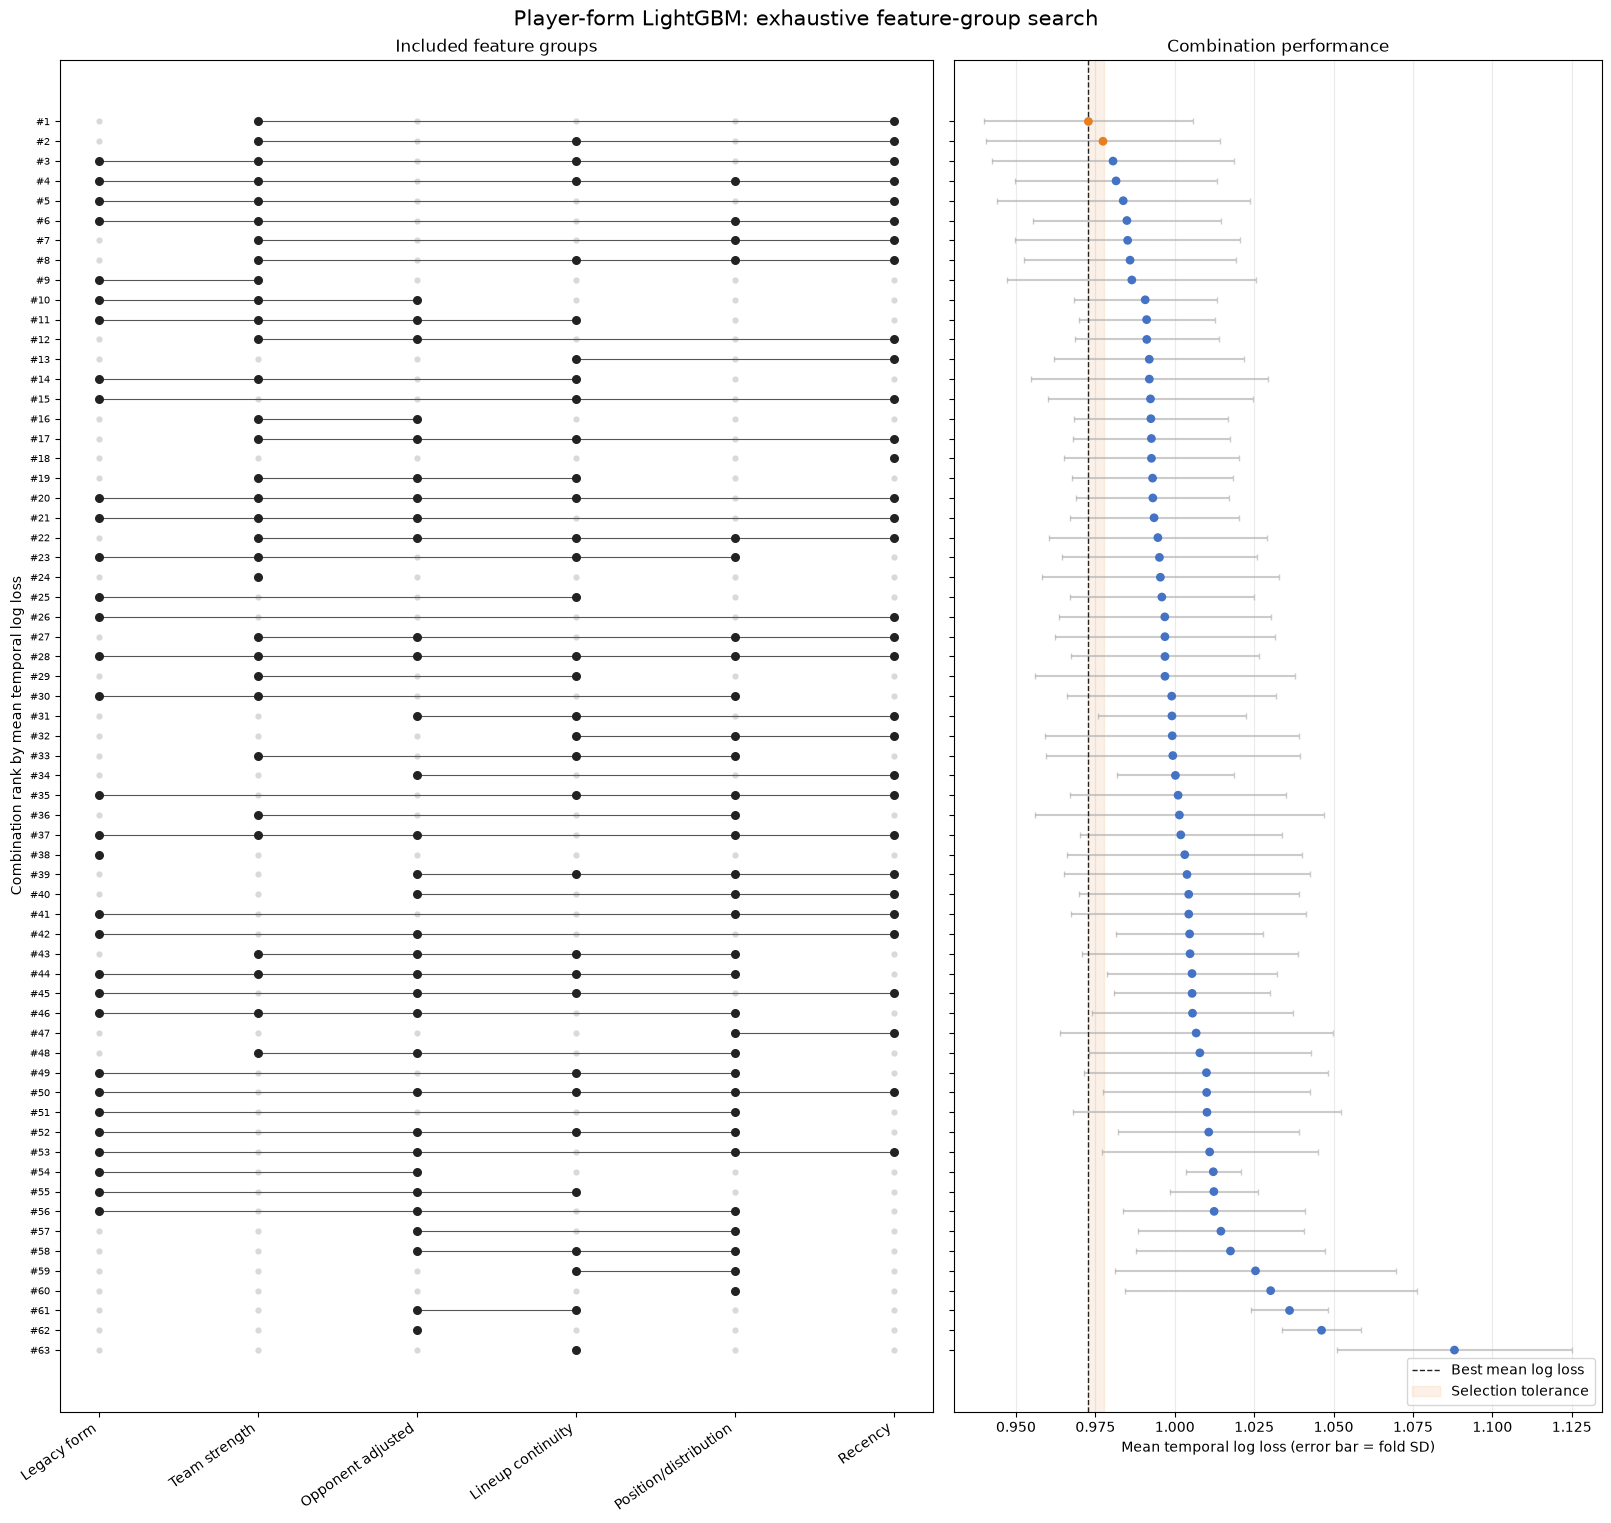

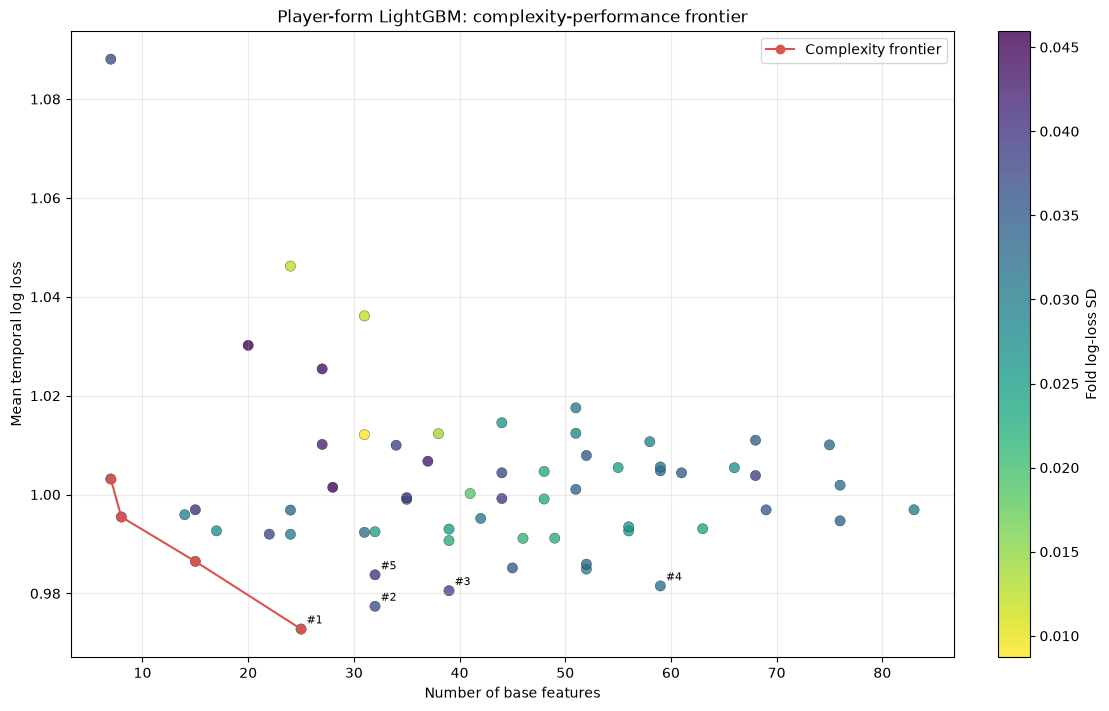

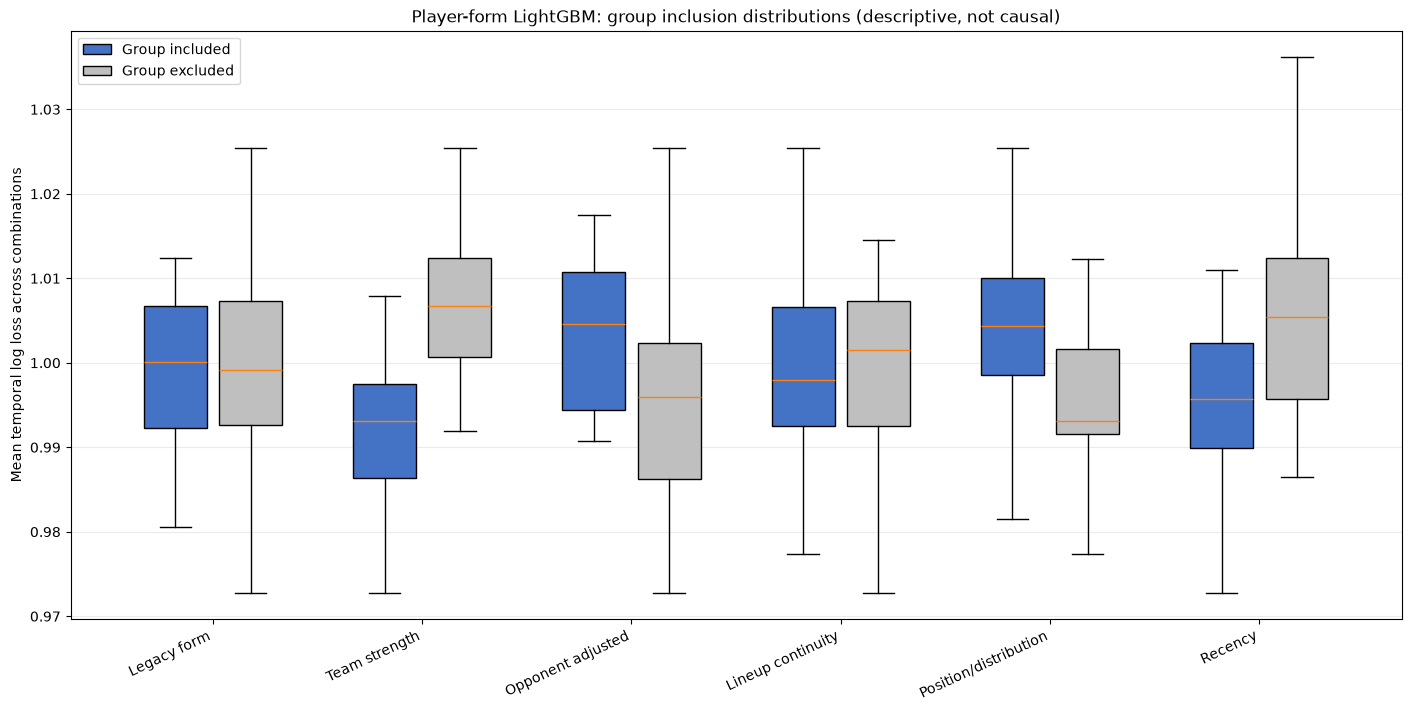

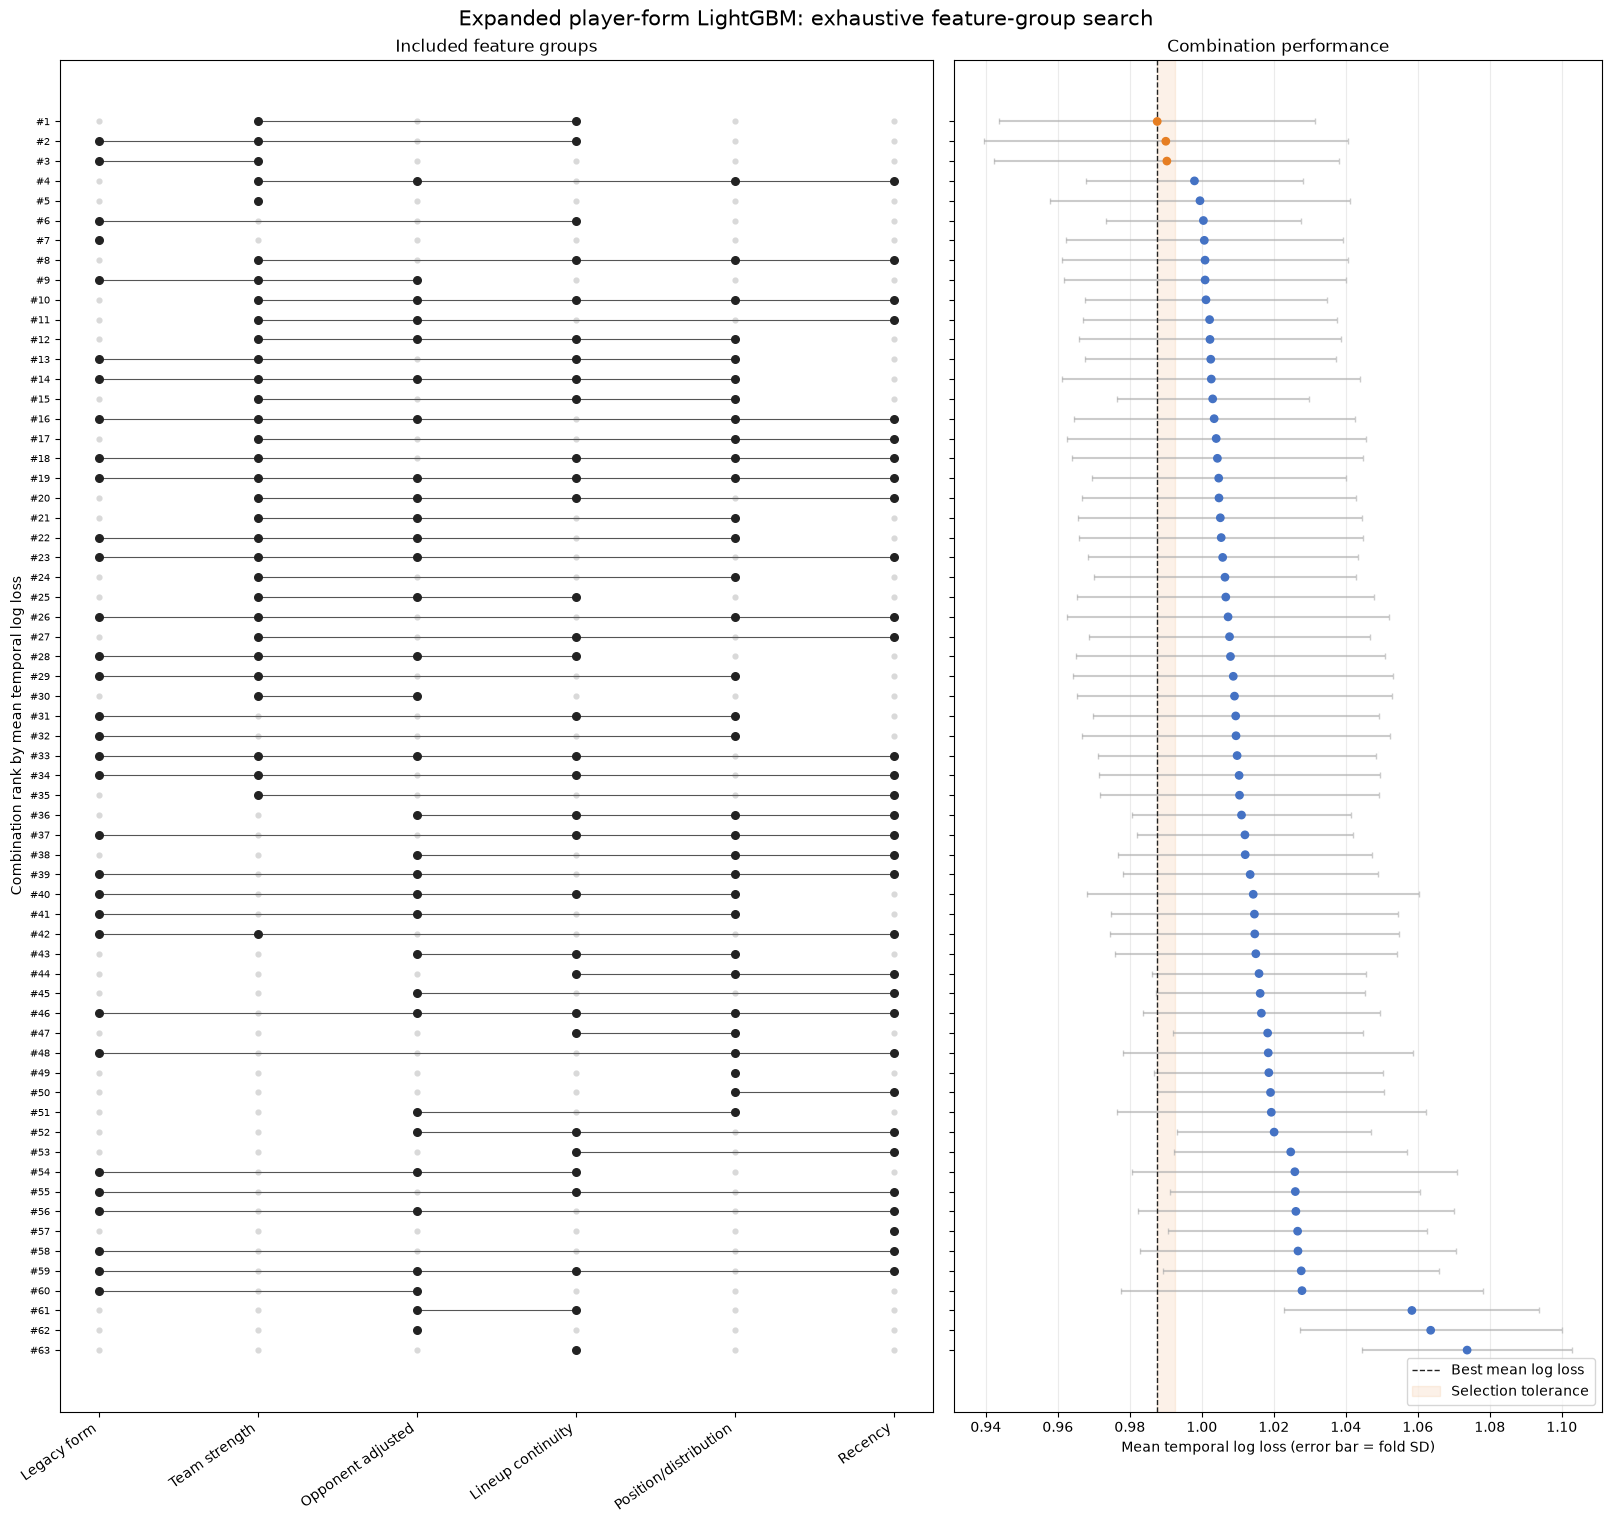

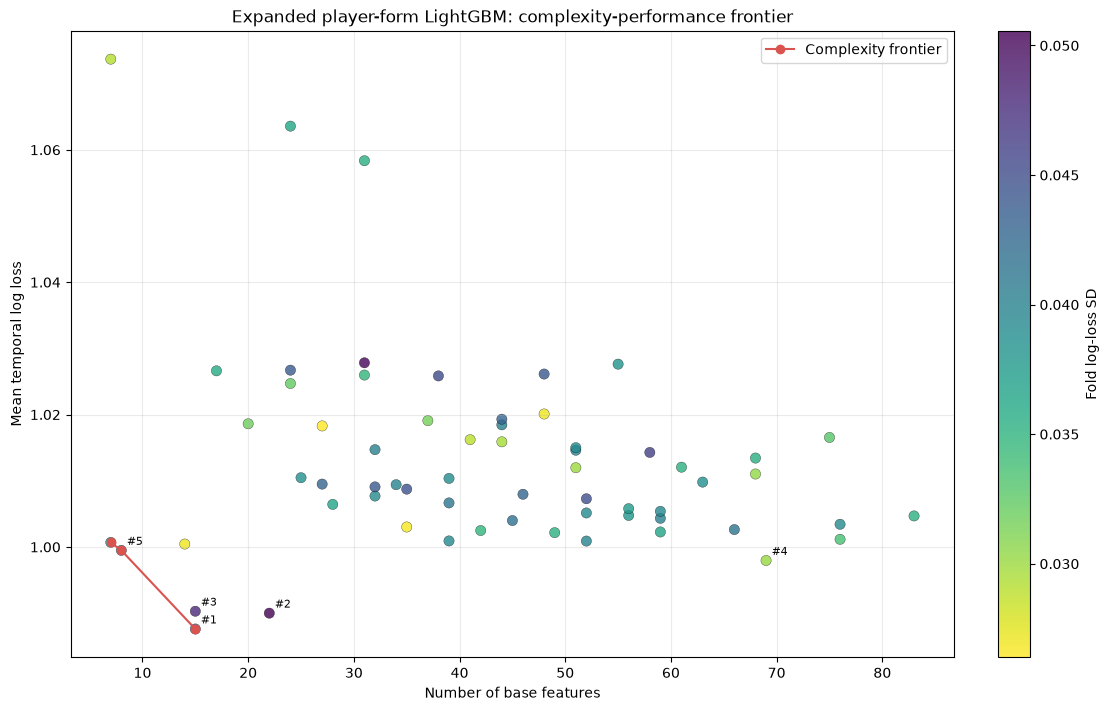

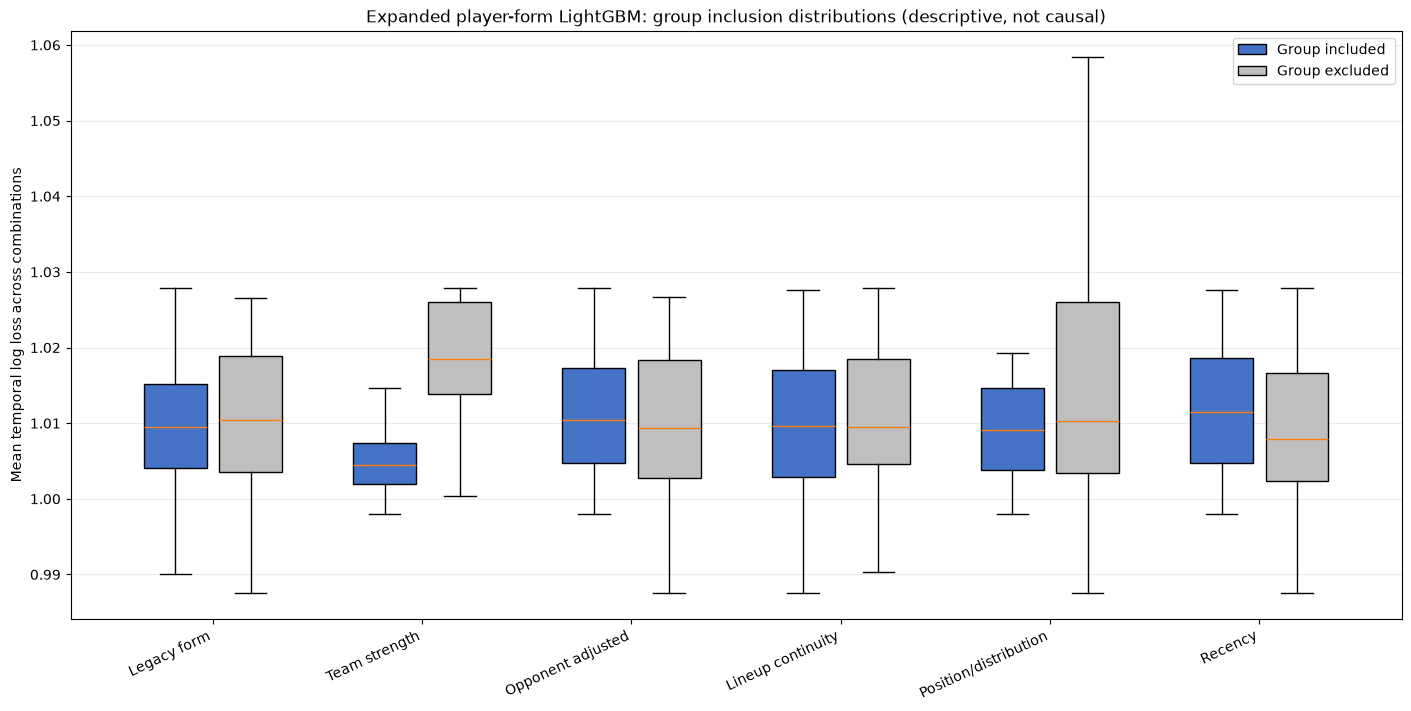

[WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/feature_removal_help/player_form_logistic_combination_matrix.png'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/feature_removal_help/player_form_logistic_complexity_frontier.png'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/feature_removal_help/player_form_logistic_group_effects.png'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/feature_removal_help/market_plus_player_form_combination_matrix.png'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/feature_removal_help/market_plus_player_form_complexity_frontier.png'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/feature_removal_help/market_plus_player_form_group_effects.png'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/feature_removal_h

In [9]:
def plot_safe_filename(value: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", value.lower()).strip("_")

plt.style.use("default")
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white"})

group_display_names = {
    "legacy_player_form": "Legacy form",
    "team_strength": "Team strength",
    "opponent_adjusted_form": "Opponent adjusted",
    "lineup_continuity": "Lineup continuity",
    "position_and_distribution": "Position/distribution",
    "recency": "Recency",
}
exhaustive_search_images = []

for spec in MODEL_SPECS:
    model_results = addition_summary[addition_summary["model"].eq(spec.name)].copy()
    model_results = model_results.sort_values("mean_log_loss").reset_index(drop=True)
    model_results["rank"] = np.arange(1, len(model_results) + 1)
    best_loss = model_results["mean_log_loss"].min()
    model_results["within_tolerance"] = model_results["mean_log_loss"].le(
        best_loss + SELECTION_TOLERANCE
    )

    # Ranked UpSet-style matrix: every row is one of the 63 group combinations.
    figure_height = max(13, 0.24 * len(model_results))
    fig, (matrix_ax, loss_ax) = plt.subplots(
        1, 2, figsize=(16, figure_height), sharey=True,
        gridspec_kw={"width_ratios": [1.35, 1.0]}, constrained_layout=True
    )
    y_positions = np.arange(len(model_results))
    for row_index, row in model_results.iterrows():
        included = set(str(row["selected_groups"]).split("|"))
        included_positions = [index for index, group in enumerate(group_names) if group in included]
        matrix_ax.scatter(range(len(group_names)), [row_index] * len(group_names), s=12, color="#D9D9D9", zorder=1)
        if len(included_positions) > 1:
            matrix_ax.plot([min(included_positions), max(included_positions)], [row_index, row_index], color="#555555", linewidth=0.8, zorder=2)
        matrix_ax.scatter(included_positions, [row_index] * len(included_positions), s=30, color="#222222", zorder=3)
    point_colors = np.where(model_results["within_tolerance"], "#E67E22", "#4472C4")
    loss_ax.errorbar(
        model_results["mean_log_loss"], y_positions,
        xerr=model_results["fold_log_loss_std"], fmt="none", ecolor="#B0B0B0", alpha=0.65, capsize=2
    )
    loss_ax.scatter(model_results["mean_log_loss"], y_positions, c=point_colors, s=28, zorder=3)
    loss_ax.axvline(best_loss, color="#222222", linestyle="--", linewidth=1, label="Best mean log loss")
    loss_ax.axvspan(best_loss, best_loss + SELECTION_TOLERANCE, color="#E67E22", alpha=0.10, label="Selection tolerance")
    matrix_ax.set_xticks(range(len(group_names)), [group_display_names[group] for group in group_names], rotation=35, ha="right")
    matrix_ax.set_yticks(y_positions, [f"#{rank}" for rank in model_results["rank"]], fontsize=7)
    matrix_ax.set_ylabel("Combination rank by mean temporal log loss")
    matrix_ax.set_title("Included feature groups")
    loss_ax.set_xlabel("Mean temporal log loss (error bar = fold SD)")
    loss_ax.set_title("Combination performance")
    loss_ax.grid(axis="x", alpha=0.25)
    loss_ax.legend(loc="lower right")
    matrix_ax.invert_yaxis()
    fig.suptitle(f"{spec.label}: exhaustive feature-group search", fontsize=15)
    matrix_path = IMAGE_DIR / f"{plot_safe_filename(spec.name)}_combination_matrix.png"
    fig.savefig(matrix_path, dpi=300, bbox_inches="tight")
    exhaustive_search_images.append(matrix_path)
    plt.show()
    plt.close(fig)

    # Complexity frontier: highlight combinations not dominated by a simpler, better result.
    complexity = model_results.groupby("base_feature_count", as_index=False)["mean_log_loss"].min().sort_values("base_feature_count")
    complexity["running_best"] = complexity["mean_log_loss"].cummin()
    frontier = complexity[complexity["mean_log_loss"].eq(complexity["running_best"])]
    fig, ax = plt.subplots(figsize=(11, 7), constrained_layout=True)
    scatter = ax.scatter(
        model_results["base_feature_count"], model_results["mean_log_loss"],
        c=model_results["fold_log_loss_std"], cmap="viridis_r", s=55, alpha=0.8, edgecolor="black", linewidth=0.25
    )
    ax.plot(frontier["base_feature_count"], frontier["mean_log_loss"], color="#D9534F", marker="o", linewidth=1.5, label="Complexity frontier")
    for _, row in model_results.head(5).iterrows():
        ax.annotate(f"#{int(row['rank'])}", (row["base_feature_count"], row["mean_log_loss"]), xytext=(4, 4), textcoords="offset points", fontsize=8)
    fig.colorbar(scatter, ax=ax, label="Fold log-loss SD")
    ax.set_title(f"{spec.label}: complexity-performance frontier")
    ax.set_xlabel("Number of base features")
    ax.set_ylabel("Mean temporal log loss")
    ax.grid(alpha=0.25)
    ax.legend()
    frontier_path = IMAGE_DIR / f"{plot_safe_filename(spec.name)}_complexity_frontier.png"
    fig.savefig(frontier_path, dpi=300, bbox_inches="tight")
    exhaustive_search_images.append(frontier_path)
    plt.show()
    plt.close(fig)

    # Included-versus-excluded distributions summarize marginal patterns, not causal effects.
    included_losses = []
    excluded_losses = []
    for group in group_names:
        membership = model_results["selected_groups"].str.split("|").map(lambda groups: group in groups)
        included_losses.append(model_results.loc[membership, "mean_log_loss"].to_numpy())
        excluded_losses.append(model_results.loc[~membership, "mean_log_loss"].to_numpy())
    positions = np.arange(len(group_names))
    fig, ax = plt.subplots(figsize=(14, 7), constrained_layout=True)
    included_boxes = ax.boxplot(included_losses, positions=positions - 0.18, widths=0.30, patch_artist=True, showfliers=False)
    excluded_boxes = ax.boxplot(excluded_losses, positions=positions + 0.18, widths=0.30, patch_artist=True, showfliers=False)
    for box in included_boxes["boxes"]:
        box.set_facecolor("#4472C4")
    for box in excluded_boxes["boxes"]:
        box.set_facecolor("#BFBFBF")
    ax.set_xticks(positions, [group_display_names[group] for group in group_names], rotation=25, ha="right")
    ax.set_ylabel("Mean temporal log loss across combinations")
    ax.set_title(f"{spec.label}: group inclusion distributions (descriptive, not causal)")
    ax.grid(axis="y", alpha=0.25)
    ax.legend([included_boxes["boxes"][0], excluded_boxes["boxes"][0]], ["Group included", "Group excluded"])
    effects_path = IMAGE_DIR / f"{plot_safe_filename(spec.name)}_group_effects.png"
    fig.savefig(effects_path, dpi=300, bbox_inches="tight")
    exhaustive_search_images.append(effects_path)
    plt.show()
    plt.close(fig)

exhaustive_search_images

In [10]:
# Select a parsimonious group-level candidate for each model.
group_selected_rows = []
for model_name, group in addition_summary.groupby("model", sort=False):
    best_loss = group["mean_log_loss"].min()
    near_best = group[group["mean_log_loss"].le(best_loss + SELECTION_TOLERANCE)]
    selected = near_best.sort_values(
        ["base_feature_count", "mean_log_loss", "worst_fold_log_loss"],
        kind="stable",
    ).iloc[0].copy()
    selected["best_observed_log_loss"] = best_loss
    selected["selection_tolerance"] = SELECTION_TOLERANCE
    group_selected_rows.append(selected)

group_selected_feature_sets = pd.DataFrame(group_selected_rows).reset_index(drop=True)

# Cache every attempted one-feature move so repeated masks are not refitted.
refinement_candidate_rows = []
refinement_history_rows = []
refined_finalists = []

def floating_refine(spec: ModelSpec, seed_name: str, seed_features: list[str], seed_rank: int):
    current = list(seed_features)
    _, current_summary = evaluate_model_feature_set(dataset, spec, f"seed_{seed_rank}", current)
    refinement_history_rows.append(
        {"model": spec.name, "seed": seed_name, "step": 0, "action": "seed",
         "feature": "", "feature_count": len(current), "mean_log_loss": current_summary["mean_log_loss"]}
    )

    for step in range(1, MAX_FLOATING_STEPS + 1):
        moves = []
        current_set = set(current)
        for action, candidates in (
            ("remove", list(current) if len(current) > 1 else []),
            ("add", [feature for feature in ALL_BASE_FEATURES if feature not in current_set]),
        ):
            for feature in candidates:
                trial = (
                    [value for value in current if value != feature]
                    if action == "remove"
                    else unique(current + [feature])
                )
                trial_name = f"floating_s{seed_rank}_t{step}_{action}_{feature}"
                _, summary = evaluate_model_feature_set(dataset, spec, trial_name, trial)
                moves.append((summary["mean_log_loss"], action, feature, trial, summary))

        if not moves:
            break
        moves.sort(key=lambda move: (move[0], len(move[3]), move[1], move[2]))
        best_loss, best_action, best_feature, best_trial, best_summary = moves[0]
        accepted = best_loss < current_summary["mean_log_loss"] - MIN_REFINEMENT_IMPROVEMENT
        for loss, action, feature, trial, summary in moves:
            refinement_candidate_rows.append(
                {"model": spec.name, "seed": seed_name, "step": step, "action": action,
                 "feature": feature, "feature_count": len(trial), "mean_log_loss": loss,
                 "accepted": bool(accepted and action == best_action and feature == best_feature)}
            )
        if not accepted:
            break
        current = best_trial
        current_summary = best_summary
        refinement_history_rows.append(
            {"model": spec.name, "seed": seed_name, "step": step, "action": best_action,
             "feature": best_feature, "feature_count": len(current), "mean_log_loss": best_loss}
        )

    return current, current_summary

for spec in MODEL_SPECS:
    model_results = addition_summary[addition_summary["model"].eq(spec.name)].copy()
    parsimonious_name = group_selected_feature_sets.loc[
        group_selected_feature_sets["model"].eq(spec.name), "feature_set"
    ].iloc[0]
    ranked_names = model_results.sort_values("mean_log_loss")["feature_set"].tolist()
    seed_names = unique([parsimonious_name] + ranked_names)[:REFINEMENT_SEEDS]
    for seed_rank, seed_name in enumerate(seed_names, start=1):
        features, summary = floating_refine(
            spec, seed_name, CANDIDATE_FEATURE_SETS[seed_name], seed_rank
        )
        refined_finalists.append(
            {**summary, "seed_feature_set": seed_name, "features": features,
             "base_feature_count": len(features), "selection_source": "floating_refinement"}
        )
        pd.DataFrame(refinement_candidate_rows).to_csv(
            OUTPUT_DIR / "floating_refinement_candidates_checkpoint.csv", index=False
        )
        pd.DataFrame(refinement_history_rows).to_csv(
            OUTPUT_DIR / "floating_refinement_history_checkpoint.csv", index=False
        )

refinement_candidates = pd.DataFrame(refinement_candidate_rows)
refinement_history = pd.DataFrame(refinement_history_rows)
refined_finalists = pd.DataFrame(refined_finalists)

# Select among the parsimonious group candidate and refined finalists.
selected_rows = []
selected_feature_map = {}
for spec in MODEL_SPECS:
    group_row = group_selected_feature_sets[group_selected_feature_sets["model"].eq(spec.name)].iloc[0]
    candidates = [
        {**group_row.to_dict(), "features": CANDIDATE_FEATURE_SETS[group_row["feature_set"]],
         "seed_feature_set": group_row["feature_set"], "selection_source": "group_search"}
    ]
    candidates.extend(refined_finalists[refined_finalists["model"].eq(spec.name)].to_dict("records"))
    best_loss = min(candidate["mean_log_loss"] for candidate in candidates)
    near_best = [candidate for candidate in candidates if candidate["mean_log_loss"] <= best_loss + SELECTION_TOLERANCE]
    selected = sorted(near_best, key=lambda candidate: (len(candidate["features"]), candidate["mean_log_loss"], candidate["worst_fold_log_loss"]))[0]
    selected["feature_set"] = f"final_{spec.name}"
    selected["base_feature_count"] = len(selected["features"])
    selected["best_observed_log_loss"] = best_loss
    selected["selection_tolerance"] = SELECTION_TOLERANCE
    selected_feature_map[spec.name] = list(selected["features"])
    selected_rows.append(selected)

selected_feature_sets = pd.DataFrame(selected_rows).reset_index(drop=True)
selected_feature_sets.drop(columns=["features"], errors="ignore")

,model,model_label,feature_set,base_feature_count,model_column_count,mean_log_loss,worst_fold_log_loss,fold_log_loss_std,mean_brier_score,seed_feature_set,selection_source,best_observed_log_loss,selection_tolerance
0,player_form_logistic,Player-form logistic,final_player_form_logistic,9,9,0.956768,1.006722,0.036039,0.563222,legacy_player_form,floating_refinement,0.956768,0.005
1,market_plus_player_form,Market + player-form logistic,final_market_plus_player_form,5,5,0.933654,0.969228,0.037673,0.547299,legacy_player_form,floating_refinement,0.933654,0.005
2,dixon_coles_player_form,Dixon–Coles + player form,final_dixon_coles_player_form,7,7,0.943662,0.971072,0.033168,0.557647,legacy_player_form,floating_refinement,0.943272,0.005
3,player_form_lightgbm,Player-form LightGBM,final_player_form_lightgbm,23,23,0.955962,0.986715,0.032795,0.565033,team_strength + recency,floating_refinement,0.955962,0.005
4,expanded_player_form_lightgbm,Expanded player-form LightGBM,final_expanded_player_form_lightgbm,17,34,0.959112,1.005028,0.039592,0.565335,team_strength + lineup_continuity,floating_refinement,0.959112,0.005


## Phase B: floating individual-feature refinement and removal diagnostics

The strongest group candidates seed a bounded floating search. At each step every one-feature removal and addition is evaluated, and the best move is accepted only when it improves temporal log loss by the declared minimum. Final group and individual removals are then measured relative to the selected refined set.

In [11]:
removal_fold_frames = []
removal_summary_rows = []
individual_removal_rows = []

for spec in MODEL_SPECS:
    selected_row = selected_feature_sets[selected_feature_sets["model"].eq(spec.name)].iloc[0]
    selected_name = selected_row["feature_set"]
    selected_features = selected_feature_map[spec.name]

    full_folds, full_summary = evaluate_model_feature_set(
        dataset, spec, "selected_full", selected_features
    )
    full_summary["removed_group"] = "none"
    full_summary["selected_feature_set"] = selected_name
    full_summary["log_loss_difference_from_selected"] = 0.0
    removal_fold_frames.append(full_folds)
    removal_summary_rows.append(full_summary)

    selected_set = set(selected_features)
    for group_name, group_features in FEATURE_GROUPS.items():
        included = [feature for feature in group_features if feature in selected_set]
        if not included:
            continue
        remaining = [feature for feature in selected_features if feature not in set(included)]
        if not remaining:
            continue
        removal_name = f"without_{group_name}"
        folds, summary = evaluate_model_feature_set(dataset, spec, removal_name, remaining)
        summary["removed_group"] = group_name
        summary["selected_feature_set"] = selected_name
        summary["log_loss_difference_from_selected"] = (
            summary["mean_log_loss"] - full_summary["mean_log_loss"]
        )
        removal_fold_frames.append(folds)
        removal_summary_rows.append(summary)

    for feature in selected_features:
        remaining = [value for value in selected_features if value != feature]
        if not remaining:
            continue
        _, summary = evaluate_model_feature_set(
            dataset, spec, f"without_feature_{feature}", remaining
        )
        individual_removal_rows.append(
            {**summary, "removed_feature": feature, "selected_feature_set": selected_name,
             "log_loss_difference_from_selected": summary["mean_log_loss"] - full_summary["mean_log_loss"]}
        )

removal_folds = pd.concat(removal_fold_frames, ignore_index=True)
removal_summary = pd.DataFrame(removal_summary_rows)
individual_removal_summary = pd.DataFrame(individual_removal_rows)
removal_summary.sort_values(["model", "log_loss_difference_from_selected"], ascending=[True, False])

,model,model_label,feature_set,base_feature_count,model_column_count,mean_log_loss,worst_fold_log_loss,fold_log_loss_std,mean_brier_score,removed_group,selected_feature_set,log_loss_difference_from_selected
11,dixon_coles_player_form,Dixon–Coles + player form,without_position_and_distribution,4,4,0.950671,0.989002,0.037097,0.562846,position_and_distribution,final_dixon_coles_player_form,0.007009
10,dixon_coles_player_form,Dixon–Coles + player form,without_legacy_player_form,3,3,0.949229,0.985542,0.035461,0.561916,legacy_player_form,final_dixon_coles_player_form,0.005566
9,dixon_coles_player_form,Dixon–Coles + player form,selected_full,7,7,0.943662,0.971072,0.033168,0.557647,none,final_dixon_coles_player_form,0.000000
18,expanded_player_form_lightgbm,Expanded player-form LightGBM,without_team_strength,11,22,1.006089,1.038064,0.021634,0.597661,team_strength,final_expanded_player_form_lightgbm,0.046977
20,expanded_player_form_lightgbm,Expanded player-form LightGBM,without_lineup_continuity,10,20,0.976425,1.017505,0.035034,0.577456,lineup_continuity,final_expanded_player_form_lightgbm,0.017314
19,expanded_player_form_lightgbm,Expanded player-form LightGBM,without_opponent_adjusted_form,16,32,0.973830,1.007879,0.038543,0.574517,opponent_adjusted_form,final_expanded_player_form_lightgbm,0.014719
21,expanded_player_form_lightgbm,Expanded player-form LightGBM,without_position_and_distribution,14,28,0.966890,1.020507,0.044287,0.570118,position_and_distribution,final_expanded_player_form_lightgbm,0.007778
17,expanded_player_form_lightgbm,Expanded player-form LightGBM,selected_full,17,34,0.959112,1.005028,0.039592,0.565335,none,final_expanded_player_form_lightgbm,0.000000
7,market_plus_player_form,Market + player-form logistic,without_lineup_continuity,4,4,0.935189,0.973164,0.037195,0.547763,lineup_continuity,final_market_plus_player_form,0.001535
8,market_plus_player_form,Market + player-form logistic,without_position_and_distribution,4,4,0.935022,0.968102,0.037557,0.547658,position_and_distribution,final_market_plus_player_form,0.001368


## Save one feature-removal image per model

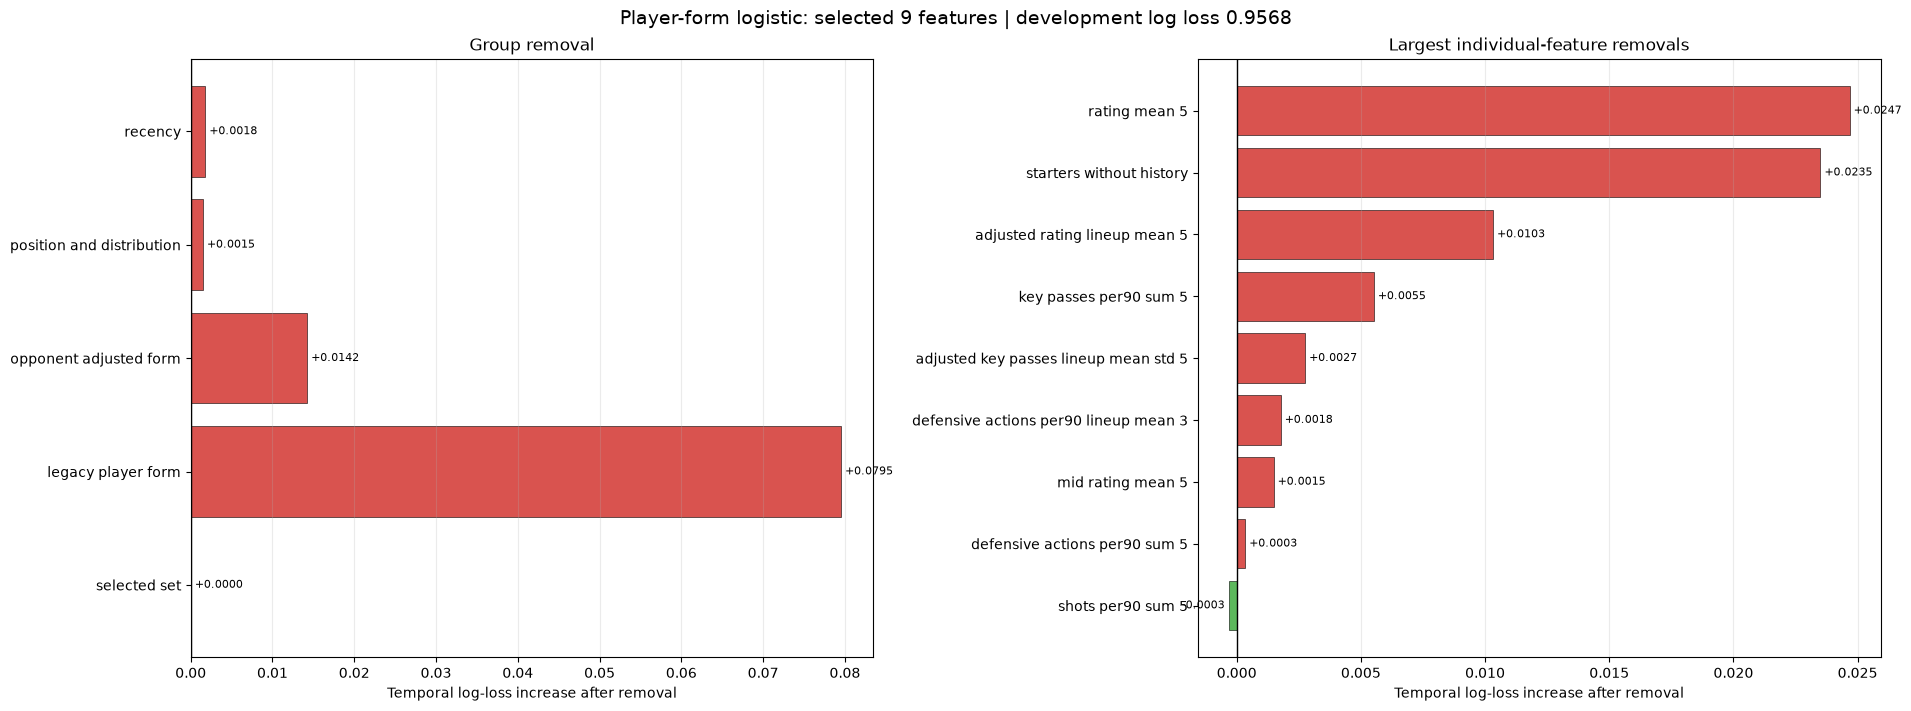

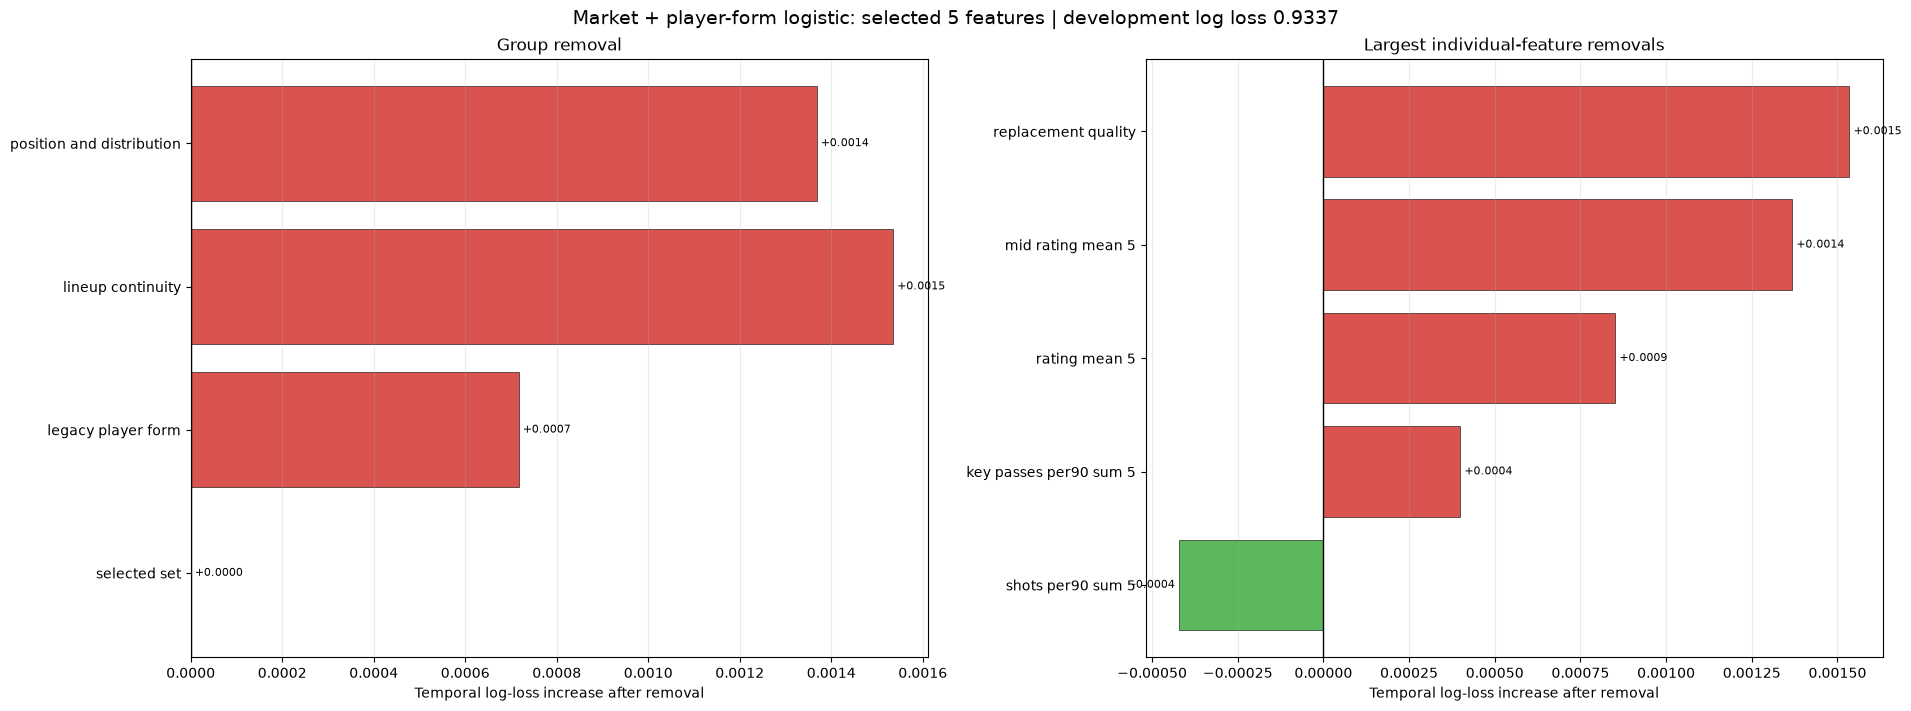

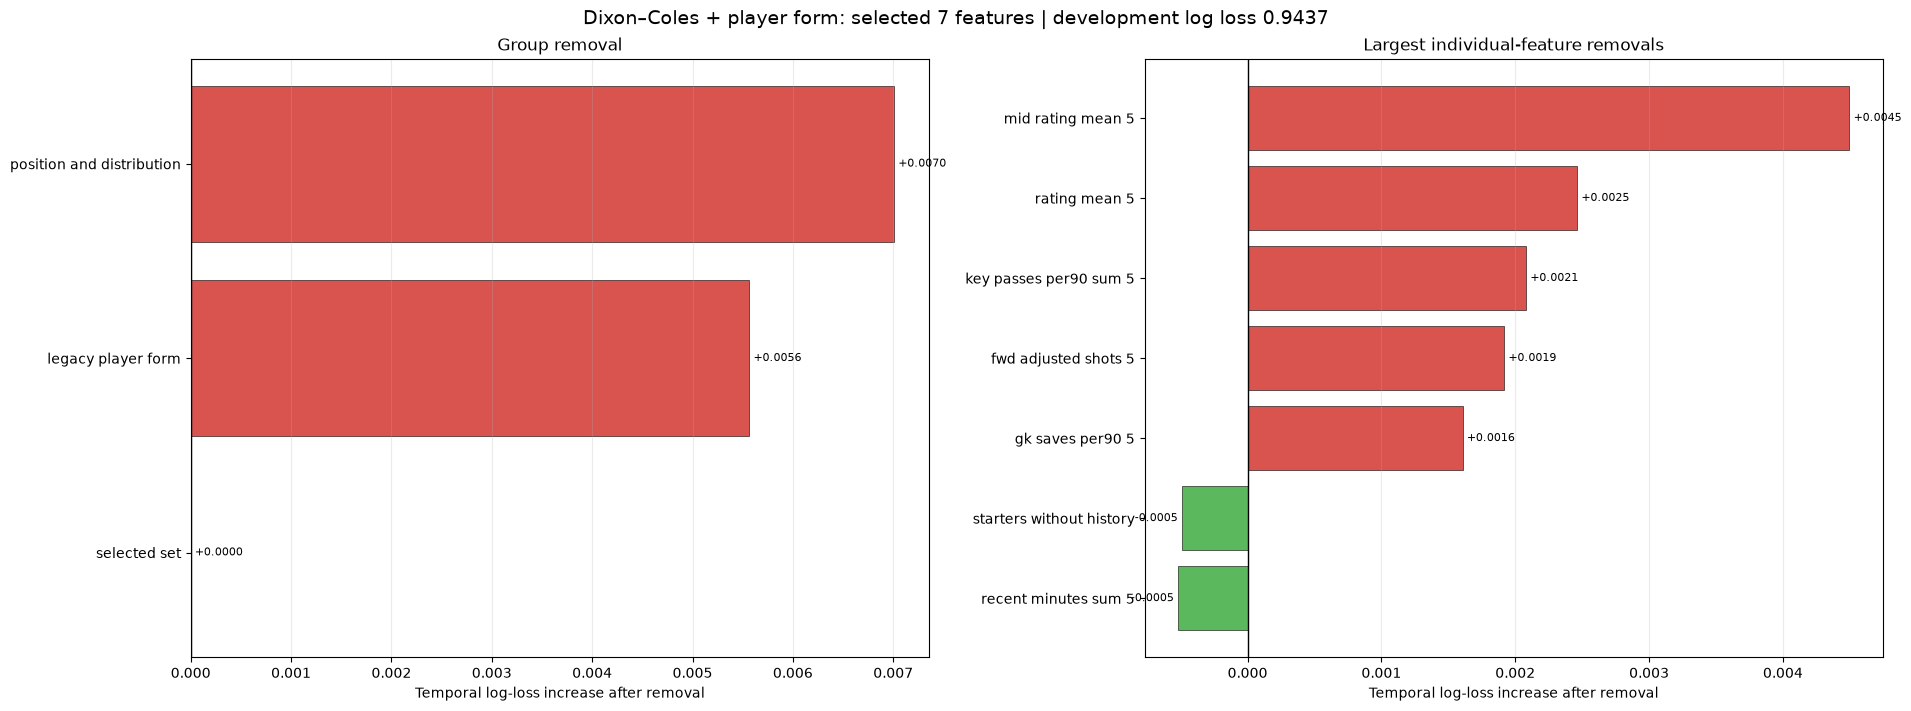

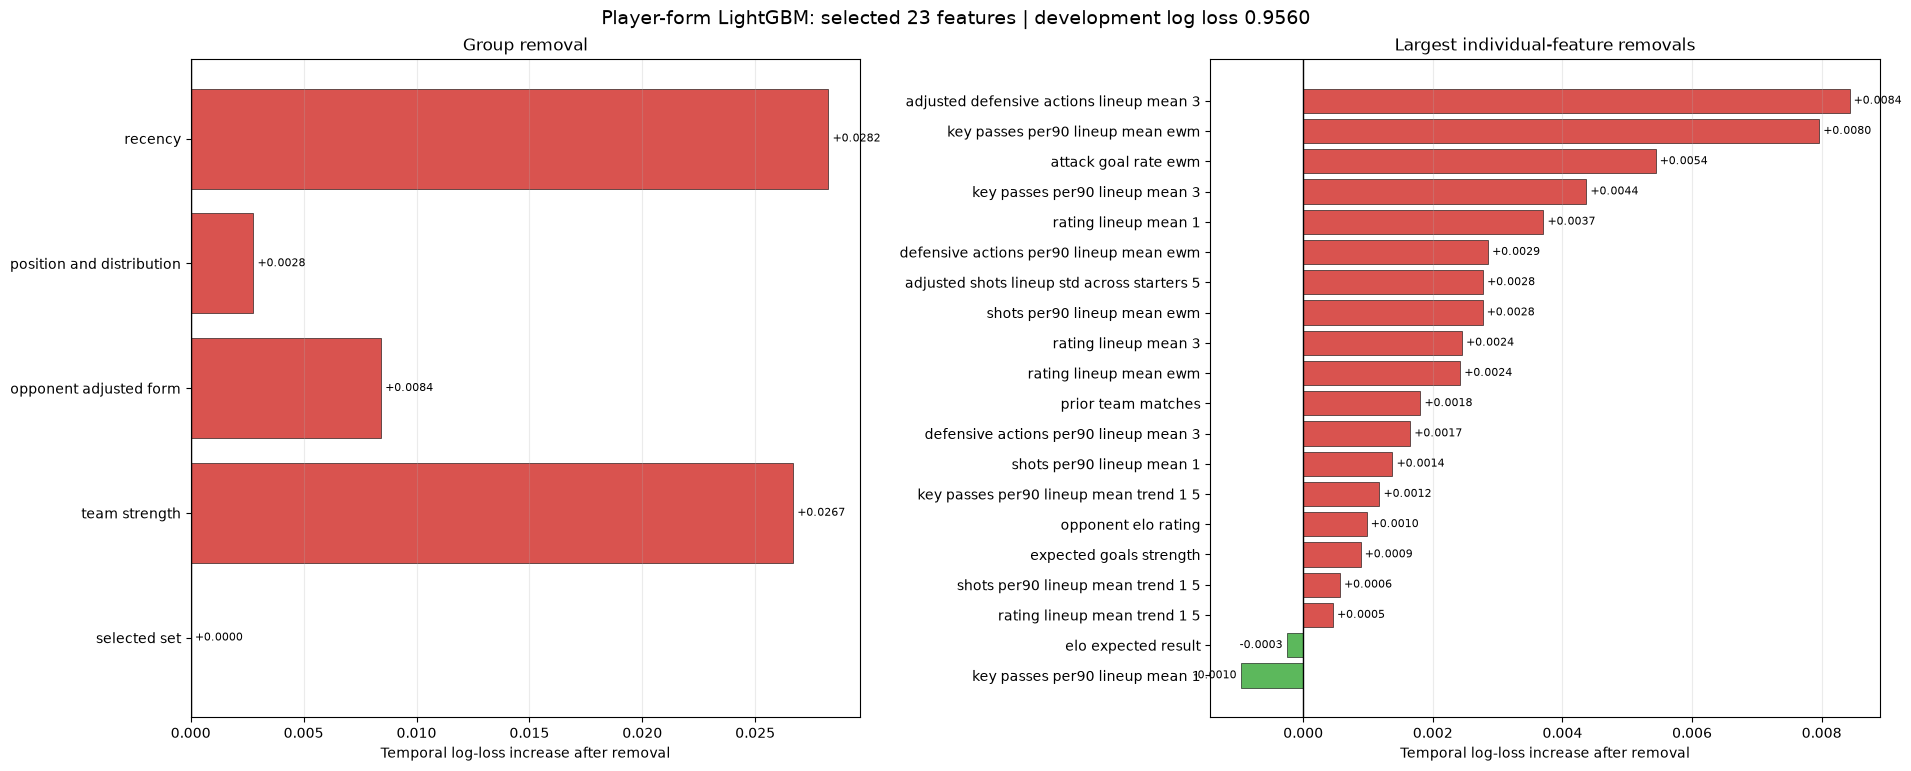

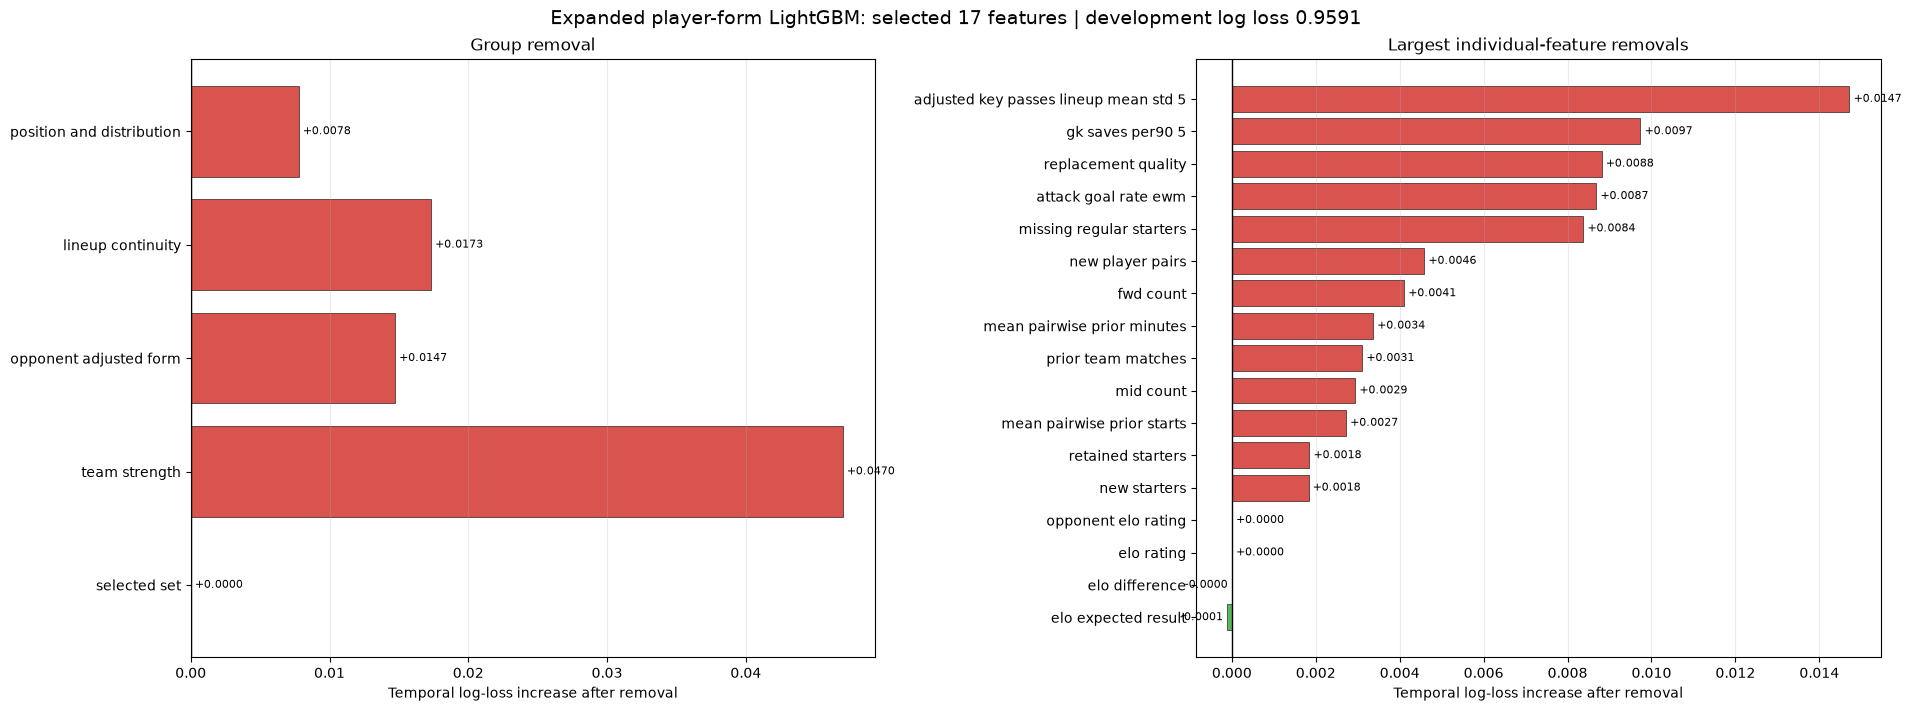

[WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/feature_removal_help/player_form_logistic_feature_group_removal.png'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/feature_removal_help/market_plus_player_form_feature_group_removal.png'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/feature_removal_help/dixon_coles_player_form_feature_group_removal.png'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/feature_removal_help/player_form_lightgbm_feature_group_removal.png'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/feature_removal_help/expanded_player_form_lightgbm_feature_group_removal.png')]

In [12]:
def safe_filename(value: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", value.lower()).strip("_")

saved_images = []
plt.style.use("default")
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white"})

for spec in MODEL_SPECS:
    group_rows = removal_summary[removal_summary["model"].eq(spec.name)].copy()
    feature_rows = (
        individual_removal_summary[individual_removal_summary["model"].eq(spec.name)].copy()
        if not individual_removal_summary.empty
        else pd.DataFrame(columns=["removed_feature", "log_loss_difference_from_selected"])
    )
    feature_rows["absolute_difference"] = feature_rows["log_loss_difference_from_selected"].abs()
    feature_rows = feature_rows.nlargest(20, "absolute_difference").sort_values(
        "log_loss_difference_from_selected"
    )

    figure_height = max(7, 0.38 * max(len(group_rows), len(feature_rows)))
    fig, axes = plt.subplots(1, 2, figsize=(19, figure_height), constrained_layout=True)
    panels = [
        (axes[0], group_rows, "removed_group", "Group removal"),
        (axes[1], feature_rows, "removed_feature", "Largest individual-feature removals"),
    ]
    for ax, rows, label_column, title in panels:
        labels = rows[label_column].map(
            lambda value: "selected set" if value == "none" else str(value).replace("_", " ")
        )
        differences = rows["log_loss_difference_from_selected"]
        colors = ["#D9534F" if value > 0 else "#5CB85C" if value < 0 else "#4472C4" for value in differences]
        bars = ax.barh(labels, differences, color=colors, edgecolor="black", linewidth=0.4)
        ax.axvline(0, color="black", linewidth=1)
        ax.bar_label(bars, labels=[f"{value:+.4f}" for value in differences], padding=3, fontsize=8)
        ax.set_title(title)
        ax.set_xlabel("Temporal log-loss increase after removal")
        ax.grid(axis="x", alpha=0.25)

    selected_loss = group_rows.loc[group_rows["removed_group"].eq("none"), "mean_log_loss"].iloc[0]
    selected_count = len(selected_feature_map[spec.name])
    fig.suptitle(
        f"{spec.label}: selected {selected_count} features | development log loss {selected_loss:.4f}",
        fontsize=14,
    )
    image_path = IMAGE_DIR / f"{safe_filename(spec.name)}_feature_group_removal.png"
    fig.savefig(image_path, dpi=300, bbox_inches="tight")
    saved_images.append(image_path)
    plt.show()

saved_images

In [13]:
addition_folds.to_csv(OUTPUT_DIR / "feature_group_combination_folds.csv", index=False)
addition_summary.to_csv(OUTPUT_DIR / "feature_group_combination_summary.csv", index=False)
group_selected_feature_sets.to_csv(OUTPUT_DIR / "group_selected_feature_sets.csv", index=False)
refinement_candidates.to_csv(OUTPUT_DIR / "floating_refinement_candidates.csv", index=False)
refinement_history.to_csv(OUTPUT_DIR / "floating_refinement_history.csv", index=False)
refined_finalists.to_csv(OUTPUT_DIR / "floating_refinement_finalists.csv", index=False)
selected_feature_sets.to_csv(OUTPUT_DIR / "selected_feature_sets.csv", index=False)
selected_feature_manifest = pd.DataFrame(
    [{"model": model, "feature": feature} for model, features in selected_feature_map.items() for feature in features]
)
selected_feature_manifest.to_csv(OUTPUT_DIR / "selected_feature_manifest.csv", index=False)
removal_folds.to_csv(OUTPUT_DIR / "feature_group_removal_folds.csv", index=False)
removal_summary.to_csv(OUTPUT_DIR / "feature_group_removal_summary.csv", index=False)
individual_removal_summary.to_csv(OUTPUT_DIR / "individual_feature_removal_summary.csv", index=False)
dixon_coles_diagnostics = pd.concat(dixon_coles_diagnostic_frames, ignore_index=True) if dixon_coles_diagnostic_frames else pd.DataFrame()
dixon_coles_diagnostics.to_csv(OUTPUT_DIR / "dixon_coles_prediction_diagnostics.csv", index=False)

print(f"Saved tables to {OUTPUT_DIR}")
print(f"Saved {len(saved_images)} model-specific images to {IMAGE_DIR}")

Saved tables to C:\Users\skous\Super-League-odds-research\artifacts\scotland_feature_group_selection
Saved 5 model-specific images to C:\Users\skous\Super-League-odds-research\scotland_research\visuals\feature_removal_help


## Results and conclusion

| Model | Selected features | Development log loss | Worst season |
|---|---:|---:|---:|
| Market + player-form logistic | 5 | 0.9337 | 0.9692 |
| Dixon–Coles + player form | 7 | 0.9437 | 0.9711 |
| Player-form LightGBM | 23 | 0.9560 | 0.9867 |
| Player-form logistic | 9 | 0.9568 | 1.0067 |
| Expanded player-form LightGBM | 17 | 0.9591 | 1.0050 |

The exhaustive search shows that feature value is strongly model-dependent. The linear player-form model performs best with a small legacy-form-led subset, while the standard LightGBM benefits primarily from team-strength and recency information and the expanded LightGBM from team strength and lineup continuity. Adding most available variables indiscriminately generally worsens the linear models and increases seasonal instability. Dixon–Coles is especially incompatible with team-strength variables used as unrestricted player-form shifts: combinations containing that group form a visibly poor and unstable performance regime.

Floating refinement improves all five families relative to their best whole-group candidates. After refinement, standard LightGBM (0.9560) and logistic regression (0.9568) are effectively tied, while expanded LightGBM remains slightly worse (0.9591). These results therefore do not establish a general nonlinear advantage; they show that nonlinear models become competitive when given targeted strength and recency features. The market-augmented model is best overall, but it has an information advantage and should not be interpreted as a like-for-like algorithm comparison.